# PFAS Auxiliary QSAR Results Summary

Summarize `benchmark_results/pfas_aux_qsar_full` from `run_autoqsar_ga_benchmarks.py --pfas-aux-workbook`, rebuilding the displayed tables from per-dataset outputs when resumed runs leave top-level combined CSVs stale.


In [19]:
from pathlib import Path
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except Exception:
    def display(value):
        print(value)

ROOT = Path.cwd()
if ROOT.name == 'portable_colab_qsar_bundle':
    ROOT = ROOT.parent

# Set RUN_DIR explicitly to compare a specific run, or leave as None to use the latest unified PFAS workbook run.
RUN_DIR = None
PREFERRED_RUN_DIR = ROOT / 'benchmark_results' / 'pfas_aux_qsar_full'


def _read_json(path):
    try:
        return json.loads(path.read_text(encoding='utf-8'))
    except Exception:
        return {}


def _file_mtime(path):
    try:
        return path.stat().st_mtime
    except OSError:
        return 0.0


def _run_sort_key(run_dir):
    files = [run_dir / name for name in [
        'run_complete.json', 'run_config.json', 'summary_metrics.csv', 'predictions.csv',
        'tabpfn_daily_budget_estimate.csv', 'step_runtime_summary.csv'
    ]]
    child_files = list(run_dir.glob('*/metrics.csv')) + list(run_dir.glob('*/predictions.csv'))
    return max([_file_mtime(run_dir), *[_file_mtime(path) for path in files + child_files]])


def _is_unified_pfas_aux_run(run_dir):
    has_top_level = (run_dir / 'summary_metrics.csv').exists() and (run_dir / 'predictions.csv').exists()
    has_child_outputs = any(run_dir.glob('*/metrics.csv')) and any(run_dir.glob('*/predictions.csv'))
    if not has_top_level and not has_child_outputs:
        return False
    config = _read_json(run_dir / 'run_config.json')
    if str(config.get('pfas_aux_workbook', '')).strip():
        return True
    preview_path = run_dir / 'summary_metrics.csv'
    if not preview_path.exists():
        child_metrics = sorted(run_dir.glob('*/metrics.csv'))
        preview_path = child_metrics[0] if child_metrics else preview_path
    try:
        preview = pd.read_csv(preview_path, nrows=25)
    except Exception:
        return False
    if 'benchmark_suite' in preview.columns and preview['benchmark_suite'].astype(str).str.eq('pfas_aux_workbook').any():
        return True
    return {'sheet', 'target', 'smiles_subset'}.issubset(set(preview.columns))


def find_latest_pfas_aux_run(root):
    if PREFERRED_RUN_DIR.exists() and _is_unified_pfas_aux_run(PREFERRED_RUN_DIR):
        return PREFERRED_RUN_DIR
    benchmark_root = root / 'benchmark_results'
    candidates = [path for path in benchmark_root.glob('pfas_aux_qsar*') if path.is_dir() and _is_unified_pfas_aux_run(path)]
    if not candidates:
        raise FileNotFoundError('No compatible PFAS auxiliary benchmark run found under benchmark_results/. Expected a run from run_autoqsar_ga_benchmarks.py --pfas-aux-workbook with summary_metrics.csv/predictions.csv or per-dataset outputs.')
    return sorted(candidates, key=_run_sort_key)[-1]


if RUN_DIR is None:
    RUN_DIR = find_latest_pfas_aux_run(ROOT)
else:
    RUN_DIR = Path(RUN_DIR)
    if not RUN_DIR.is_absolute():
        RUN_DIR = ROOT / RUN_DIR

summary_path = RUN_DIR / 'summary_metrics.csv'
predictions_path = RUN_DIR / 'predictions.csv'
config_path = RUN_DIR / 'run_config.json'
complete_path = RUN_DIR / 'run_complete.json'
run_config = _read_json(config_path) if config_path.exists() else {}
run_complete = _read_json(complete_path) if complete_path.exists() else {}


def _read_csv_if_exists(path):
    return pd.read_csv(path) if path.exists() else pd.DataFrame()


def load_top_level_outputs(run_dir):
    return _read_csv_if_exists(run_dir / 'summary_metrics.csv'), _read_csv_if_exists(run_dir / 'predictions.csv')


def load_per_dataset_outputs(run_dir):
    metric_tables = []
    prediction_tables = []
    for dataset_dir in sorted(path for path in run_dir.iterdir() if path.is_dir()):
        metrics_path = dataset_dir / 'metrics.csv'
        predictions_path = dataset_dir / 'predictions.csv'
        if metrics_path.exists():
            table = pd.read_csv(metrics_path)
            if 'dataset' not in table.columns:
                table['dataset'] = dataset_dir.name
            table['source_dataset_dir'] = dataset_dir.name
            metric_tables.append(table)
        if predictions_path.exists():
            table = pd.read_csv(predictions_path)
            if 'dataset' not in table.columns:
                table['dataset'] = dataset_dir.name
            table['source_dataset_dir'] = dataset_dir.name
            prediction_tables.append(table)
    metrics_df = pd.concat(metric_tables, ignore_index=True, sort=False) if metric_tables else pd.DataFrame()
    predictions_df = pd.concat(prediction_tables, ignore_index=True, sort=False) if prediction_tables else pd.DataFrame()
    return metrics_df, predictions_df


top_metrics, top_predictions = load_top_level_outputs(RUN_DIR)
child_metrics, child_predictions = load_per_dataset_outputs(RUN_DIR)
child_latest = max([0.0, *[_file_mtime(path) for path in RUN_DIR.glob('*/metrics.csv')], *[_file_mtime(path) for path in RUN_DIR.glob('*/predictions.csv')]])
top_latest = max(_file_mtime(summary_path), _file_mtime(predictions_path))
use_child_outputs = (
    not child_metrics.empty
    and not child_predictions.empty
    and (
        top_metrics.empty
        or top_predictions.empty
        or child_metrics['dataset'].nunique() > top_metrics.get('dataset', pd.Series(dtype=object)).nunique()
        or child_latest > top_latest
    )
)
if use_child_outputs:
    metrics = child_metrics.copy()
    predictions = child_predictions.copy()
    output_source = 'per-dataset metrics.csv/predictions.csv files'
else:
    if top_metrics.empty:
        raise FileNotFoundError(summary_path)
    if top_predictions.empty:
        raise FileNotFoundError(predictions_path)
    metrics = top_metrics.copy()
    predictions = top_predictions.copy()
    output_source = 'top-level summary_metrics.csv/predictions.csv'



def parse_workbook_dataset_label(label, smiles_subset=''):
    raw_label = str(label or '').strip()
    raw_subset = str(smiles_subset or '').strip()
    if raw_label.lower() in {'nan', 'none', '<na>'}:
        raw_label = ''
    if raw_subset.lower() in {'nan', 'none', '<na>'}:
        raw_subset = ''
    text = raw_label.lower()
    subset_text = raw_subset.lower()

    target_family = ''
    target_key = ''
    remainder = text
    if text.startswith('hle_invivo'):
        target_family = 'HLe_invivo'
        target_key = 'hle_invivo'
        remainder = text[len('hle_invivo'):].lstrip('_')
    elif text.startswith('hle'):
        target_family = 'HLe_invivo'
        target_key = 'hle_invivo'
        remainder = text[len('hle'):].lstrip('_')
    elif text.startswith('vdss'):
        target_family = 'VDss'
        target_key = 'vdss'
        remainder = text[len('vdss'):].lstrip('_')
    else:
        target_family = raw_label.split('_')[0] if raw_label else ''
        target_key = target_family.lower()

    source_text = subset_text or remainder
    source_text = source_text.replace('pfas_only_structural', 'pfas_struct')
    source_text = source_text.replace('non_pfas_only_structural', 'nonpfas_struct')
    source_text = source_text.replace('combined_structural', 'struct')
    source_text = source_text.strip('_')

    structural_pool = 'unknown'
    pool_sort = 99
    pool_token = ''
    species = 'pooled'
    sex = 'pooled'

    tokens = [token for token in source_text.split('_') if token]
    if source_text.startswith('nonpfas') or source_text.startswith('non_pfas'):
        structural_pool = 'Non-PFAS structural'
        pool_token = 'nonpfas'
        pool_sort = 1
        tokens = [token for token in tokens if token not in {'non', 'pfas', 'nonpfas', 'only', 'structural', 'struct', 'tsca'}]
    elif source_text.startswith('pfas'):
        structural_pool = 'PFAS structural'
        pool_token = 'pfas'
        pool_sort = 0
        tokens = [token for token in tokens if token not in {'pfas', 'only', 'structural', 'struct', 'tsca'}]
    elif source_text.startswith('struct') or source_text.startswith('combined'):
        structural_pool = 'Combined structural'
        pool_token = 'combined'
        pool_sort = 2
        tokens = [token for token in tokens if token not in {'combined', 'structural', 'struct'}]
    elif 'nonpfas' in source_text or 'non_pfas' in source_text:
        structural_pool = 'Non-PFAS structural'
        pool_token = 'nonpfas'
        pool_sort = 1
    elif 'pfas' in source_text:
        structural_pool = 'PFAS structural'
        pool_token = 'pfas'
        pool_sort = 0

    species_vocab = {'human', 'monkey', 'mouse', 'rat'}
    sex_vocab = {'f', 'm', 'mf', 'not', 'not_available', 'not_reported', 'available', 'reported', 'ava', 'repor'}
    if tokens:
        for idx, token in enumerate(tokens):
            if token in species_vocab:
                species = token.title()
                tail = tokens[idx + 1:]
                if tail:
                    sex_token = '_'.join(tail)
                    sex = {
                        'f': 'F',
                        'm': 'M',
                        'mf': 'MF',
                        'not_available': 'Not available',
                        'not_ava': 'Not available',
                        'not_reported': 'Not reported',
                        'not_repor': 'Not reported',
                    }.get(sex_token, sex_token.replace('_', ' ').title())
                break

    if species == 'pooled' and ('_struct' in text or '_tsca' in text):
        species = 'All species'
        sex = 'All sexes'
    elif species == 'pooled' and pool_token:
        # Generated PFAS-only sheets have no explicit pfas token in the sheet name.
        remainder_tokens = [token for token in remainder.split('_') if token]
        if len(remainder_tokens) >= 2 and remainder_tokens[0] in species_vocab:
            species = remainder_tokens[0].title()
            sex_token = '_'.join(remainder_tokens[1:])
            sex = {'f': 'F', 'm': 'M', 'mf': 'MF'}.get(sex_token, sex_token.replace('_', ' ').title())

    if not pool_token and target_key and remainder:
        # Names like hle_invivo_human_f are PFAS-only structural derived sheets.
        remainder_tokens = [token for token in remainder.split('_') if token]
        if remainder_tokens and remainder_tokens[0] in species_vocab:
            structural_pool = 'PFAS structural'
            pool_token = 'pfas'
            pool_sort = 0
            species = remainder_tokens[0].title()
            sex_token = '_'.join(remainder_tokens[1:]) if len(remainder_tokens) > 1 else 'pooled'
            sex = {'f': 'F', 'm': 'M', 'mf': 'MF'}.get(sex_token, sex_token.replace('_', ' ').title())

    source_has_tsca = 'tsca' in text or 'tsca' in subset_text or 'tsca' in source_text
    if species == 'All species' and sex == 'All sexes':
        if pool_token == 'pfas' and source_has_tsca:
            structural_pool = 'TSCA-only PFAS with aux vars'
            pool_sort = 0
        elif pool_token == 'pfas':
            structural_pool = 'All PFAS with aux vars'
            pool_sort = 1
        elif pool_token == 'nonpfas' and source_has_tsca:
            structural_pool = 'TSCA-only non-PFAS with aux vars'
            pool_sort = 2
        elif pool_token == 'nonpfas':
            structural_pool = 'All non-PFAS with aux vars'
            pool_sort = 3

    species_sex = f'{species} / {sex}'
    dataset_group = f'{structural_pool} | {species_sex}' if structural_pool != 'unknown' else raw_label
    compact_label = f'{target_family} | {dataset_group}' if target_family else dataset_group
    return {
        'target_family': target_family,
        'target_key': target_key,
        'structural_pool': structural_pool,
        'structural_pool_sort': pool_sort,
        'species': species,
        'sex': sex,
        'species_sex': species_sex,
        'dataset_group': dataset_group,
        'compact_dataset_label': compact_label,
    }


def add_dataset_labels(df):
    df = df.copy()
    if 'dataset' not in df.columns:
        df['dataset'] = ''
    if 'dataset_label' in df.columns:
        fallback = df['sheet'] if 'sheet' in df.columns else df['dataset']
        df['dataset_label'] = df['dataset_label'].fillna(fallback).fillna(df['dataset']).astype(str)
    elif 'sheet' in df.columns:
        df['dataset_label'] = df['sheet'].fillna(df['dataset']).astype(str)
    else:
        df['dataset_label'] = df['dataset'].astype(str)
    if 'sheet' in df.columns:
        sheet_values = df['sheet'].fillna('').astype(str).str.strip()
        df.loc[sheet_values.ne(''), 'dataset_label'] = sheet_values.loc[sheet_values.ne('')]

    parsed_rows = [parse_workbook_dataset_label(label, subset) for label, subset in zip(df['dataset_label'], df.get('smiles_subset', pd.Series('', index=df.index)))]
    parsed = pd.DataFrame(parsed_rows, index=df.index)
    df = pd.concat([df.drop(columns=[column for column in parsed.columns if column in df.columns], errors='ignore'), parsed], axis=1).copy()

    if 'target' not in df.columns:
        df['target'] = df['target_family']
    else:
        df['target'] = df['target'].fillna(df['target_family']).replace('', np.nan).fillna(df['target_family'])
    if 'smiles_subset' not in df.columns:
        df['smiles_subset'] = ''
    df['smiles_subset'] = df['smiles_subset'].fillna('').astype(str)
    missing_subset = df['smiles_subset'].str.strip().eq('')
    df.loc[missing_subset, 'smiles_subset'] = df.loc[missing_subset, 'dataset_group']
    return df


metrics = add_dataset_labels(metrics)
# Harmonize labels across mixed cached rows for the same dataset. Prefer explicit workbook sheet labels.
label_lookup = {}
if 'dataset' in metrics.columns:
    for dataset_id, group in metrics.groupby('dataset', dropna=False):
        chosen = ''
        if 'sheet' in group.columns:
            sheet_values = group['sheet'].dropna().astype(str).str.strip()
            sheet_values = sheet_values[sheet_values.ne('')]
            if not sheet_values.empty:
                chosen = sheet_values.iloc[0]
        if not chosen:
            label_values = group['dataset_label'].dropna().astype(str).str.strip()
            label_values = label_values[label_values.ne('')]
            if not label_values.empty:
                chosen = label_values.iloc[0]
        if chosen:
            label_lookup[dataset_id] = chosen
    metrics['dataset_label'] = metrics['dataset'].map(label_lookup).fillna(metrics['dataset_label'])
if 'dataset' not in predictions.columns and 'dataset_label' in predictions.columns:
    predictions['dataset'] = predictions['dataset_label']
if 'dataset' not in predictions.columns:
    predictions['dataset'] = ''
if 'dataset_label' not in predictions.columns:
    predictions = predictions.merge(metrics[['dataset', 'dataset_label']].drop_duplicates(), on='dataset', how='left')
predictions['dataset_label'] = predictions['dataset_label'].fillna(predictions['dataset'])
if label_lookup:
    predictions['dataset_label'] = predictions['dataset'].map(label_lookup).fillna(predictions['dataset_label'])
if 'observed' not in predictions.columns:
    predictions['observed'] = np.nan
if 'predicted' not in predictions.columns:
    predictions['predicted'] = np.nan
if 'y_true' in predictions.columns:
    predictions['observed'] = pd.to_numeric(predictions['observed'], errors='coerce').fillna(pd.to_numeric(predictions['y_true'], errors='coerce'))
else:
    predictions['observed'] = pd.to_numeric(predictions['observed'], errors='coerce')
if 'y_pred' in predictions.columns:
    predictions['predicted'] = pd.to_numeric(predictions['predicted'], errors='coerce').fillna(pd.to_numeric(predictions['y_pred'], errors='coerce'))
else:
    predictions['predicted'] = pd.to_numeric(predictions['predicted'], errors='coerce')
if 'smiles' not in predictions.columns:
    predictions['smiles'] = np.nan
if 'QSAR_READY_SMILES' in predictions.columns:
    predictions['smiles'] = predictions['smiles'].fillna(predictions['QSAR_READY_SMILES'])
for required_column in ['dataset', 'model', 'split', 'observed', 'predicted']:
    if required_column not in predictions.columns:
        raise ValueError(f'predictions.csv is missing required column after normalization: {required_column}')

stale_top_level_outputs = (
    bool(config_path.exists())
    and bool(summary_path.exists())
    and bool(predictions_path.exists())
    and max(_file_mtime(summary_path), _file_mtime(predictions_path)) < max(_file_mtime(config_path), child_latest)
)
run_info = pd.DataFrame([
    {
        'run_dir': str(RUN_DIR),
        'selected_by': 'benchmark_results/pfas_aux_qsar_full' if RUN_DIR == PREFERRED_RUN_DIR else 'latest compatible PFAS auxiliary run',
        'display_source': output_source,
        'pfas_aux_workbook': run_config.get('pfas_aux_workbook', ''),
        'benchmark_profile': run_config.get('benchmark_profile', ''),
        'target_transform': run_config.get('target_transform', ''),
        'split_strategy': run_config.get('split_strategy', ''),
        'run_complete': complete_path.exists(),
        'summary_rows': len(metrics),
        'prediction_rows': len(predictions),
        'dataset_count': metrics['dataset'].nunique() if 'dataset' in metrics.columns else metrics['dataset_label'].nunique(),
        'model_count': metrics['model'].nunique() if 'model' in metrics.columns else np.nan,
        'top_level_outputs_stale': stale_top_level_outputs,
    }
])

print(f'Run directory: {RUN_DIR}')
print(f'Display source: {output_source}')
print(f'Metric rows: {len(metrics):,} | Prediction rows: {len(predictions):,}')
if stale_top_level_outputs and use_child_outputs:
    warnings.warn('Top-level summary_metrics.csv/predictions.csv appear older or narrower than per-dataset outputs; notebook is displaying combined per-dataset files instead.', RuntimeWarning)
elif stale_top_level_outputs:
    warnings.warn('summary_metrics.csv/predictions.csv appear older than run_config.json or per-dataset outputs.', RuntimeWarning)
run_info




Run directory: C:\Users\Scott.Coffin\OneDrive - California OEHHA\R_new\AutoQSAR\benchmark_results\pfas_aux_qsar_full
Display source: per-dataset metrics.csv/predictions.csv files
Metric rows: 629 | Prediction rows: 222,131


,run_dir,selected_by,display_source,pfas_aux_workbook,benchmark_profile,target_transform,split_strategy,run_complete,summary_rows,prediction_rows,dataset_count,model_count,top_level_outputs_stale
0,C:\Users\Scott.Coffin\OneDrive - California OE...,benchmark_results/pfas_aux_qsar_full,per-dataset metrics.csv/predictions.csv files,data\modeling_datasets_aux_features.xlsx,cost_optimized,raw,predefined,True,629,222131,29,32,True


## Model Performance

Rows are filtered to unified `run_autoqsar_ga_benchmarks.py` workflow families before ranking models. Older PFAS-specific cached rows such as `qsar_core_molecular_plus_auxiliary` are excluded.


In [20]:
allowed_workflows = {
    'conventional',
    'chemml deep learning',
    'chemprop v2',
    'maplight + gnn',
    'cfa',
    'ensemble',
}
metrics_for_display = metrics.copy()
if 'workflow' in metrics_for_display.columns:
    workflow_text = metrics_for_display['workflow'].fillna('').astype(str).str.strip().str.lower()
    metrics_for_display = metrics_for_display[workflow_text.isin(allowed_workflows)].copy()
if metrics_for_display.empty:
    raise ValueError('No rows from run_autoqsar_ga_benchmarks.py workflow families were found after filtering. Check that the selected run directory contains unified benchmark outputs.')

if 'error' in metrics_for_display.columns:
    error_text = metrics_for_display['error'].fillna('').astype(str).str.strip()
    ok = metrics_for_display[error_text.eq('')].copy()
else:
    ok = metrics_for_display.copy()
if 'status' in ok.columns:
    status_text = ok['status'].fillna('').astype(str).str.strip().str.lower()
    ok = ok[status_text.eq('') | status_text.isin(['completed', 'success', 'ok'])].copy()
for numeric_col in ['test_rmse', 'test_mae', 'test_r2', 'cv_rmse', 'cv_r2', 'n_train', 'n_test', 'structural_pool_sort']:
    if numeric_col in ok.columns:
        ok[numeric_col] = pd.to_numeric(ok[numeric_col], errors='coerce')
if 'test_rmse' in ok.columns:
    ok = ok[ok['test_rmse'].notna()].copy()
if ok.empty:
    raise ValueError('No completed model rows with test metrics found in selected PFAS auxiliary outputs.')

status_summary = pd.DataFrame({
    'all_metric_rows': [len(metrics)],
    'unified_workflow_rows': [len(metrics_for_display)],
    'displayed_completed_rows': [len(ok)],
    'datasets': [ok['dataset_label'].nunique()],
    'dataset_groups': [ok['dataset_group'].nunique() if 'dataset_group' in ok.columns else np.nan],
    'models': [ok['model'].nunique() if 'model' in ok.columns else np.nan],
    'excluded_non_unified_rows': [len(metrics) - len(metrics_for_display)],
})
display(status_summary)

display_cols = [
    'dataset_label', 'target_family', 'structural_pool', 'species', 'sex', 'dataset_group',
    'model', 'workflow', 'n_train', 'n_test', 'cv_rmse', 'cv_r2', 'test_rmse', 'test_mae', 'test_r2', 'test_spearman',
    'primary_metric', 'primary_metric_value', 'auxiliary_feature_count', 'shared_feature_matrix_cache_hit', 'cache_status', 'elapsed_seconds', 'source_dataset_dir'
]
available_cols = [c for c in display_cols if c in ok.columns]
sort_cols = [c for c in ['target_family', 'structural_pool_sort', 'species', 'sex', 'dataset_label', 'test_rmse', 'test_mae'] if c in ok.columns]
performance_table = (
    ok.sort_values(sort_cols, ascending=True)[available_cols]
    .reset_index(drop=True)
)
performance_table


,all_metric_rows,unified_workflow_rows,displayed_completed_rows,datasets,dataset_groups,models,excluded_non_unified_rows
0,629,611,547,29,20,21,18


,dataset_label,target_family,structural_pool,species,sex,dataset_group,model,workflow,n_train,n_test,...,test_mae,test_r2,test_spearman,primary_metric,primary_metric_value,auxiliary_feature_count,shared_feature_matrix_cache_hit,cache_status,elapsed_seconds,source_dataset_dir
0,HLe_invivo_pfas_tsca,HLe_invivo,TSCA-only PFAS with aux vars,All species,All sexes,TSCA-only PFAS with aux vars | All species / A...,HistGradientBoosting,conventional,164,41,...,0.540503,0.845184,0.905411,rmse,0.634530,19.0,False,NaN,57.480,hle_invivo_pfas_tsca
1,HLe_invivo_pfas_tsca,HLe_invivo,TSCA-only PFAS with aux vars,All species,All sexes,TSCA-only PFAS with aux vars | All species / A...,CFA (Combinatorial Fusion),cfa,164,41,...,0.532461,0.839321,0.902893,rmse,0.646433,19.0,False,NaN,541.974,hle_invivo_pfas_tsca
2,HLe_invivo_pfas_tsca,HLe_invivo,TSCA-only PFAS with aux vars,All species,All sexes,TSCA-only PFAS with aux vars | All species / A...,ElasticNetCV,conventional,164,41,...,0.549913,0.832774,0.895835,rmse,0.659471,19.0,False,NaN,48.110,hle_invivo_pfas_tsca
3,HLe_invivo_pfas_tsca,HLe_invivo,TSCA-only PFAS with aux vars,All species,All sexes,TSCA-only PFAS with aux vars | All species / A...,Ensemble (Weighted average (inverse train RMSE)),ensemble,164,41,...,0.497407,0.804150,0.964286,rmse,0.692014,19.0,True,NaN,3.057,hle_invivo_pfas_tsca
4,HLe_invivo_pfas_tsca,HLe_invivo,TSCA-only PFAS with aux vars,All species,All sexes,TSCA-only PFAS with aux vars | All species / A...,TabPFNRegressor,conventional,164,41,...,0.588604,0.806612,0.758691,rmse,0.709183,19.0,False,NaN,176.778,hle_invivo_pfas_tsca
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
542,vdss_nonpfas_struct,VDss,All non-PFAS with aux vars,All species,All sexes,All non-PFAS with aux vars | All species / All...,"Ensemble (OOF Stacking (RidgeCV, 2-fold))",ensemble,1441,347,...,0.417912,-1.281878,0.600000,rmse,0.508376,21.0,True,NaN,44.830,vdss_nonpfas_struct
543,vdss_nonpfas_struct,VDss,All non-PFAS with aux vars,All species,All sexes,All non-PFAS with aux vars | All species / All...,Tabular MLP,conventional,1441,347,...,0.425737,0.317617,0.546426,rmse,0.536183,21.0,False,NaN,612.422,vdss_nonpfas_struct
544,vdss_nonpfas_struct,VDss,All non-PFAS with aux vars,All species,All sexes,All non-PFAS with aux vars | All species / All...,Chemprop v2 (AttentiveFP + Selected descriptor...,Chemprop v2,1441,347,...,0.412723,0.288462,0.583935,rmse,0.547517,21.0,True,NaN,631.015,vdss_nonpfas_struct
545,vdss_nonpfas_struct,VDss,All non-PFAS with aux vars,All species,All sexes,All non-PFAS with aux vars | All species / All...,ElasticNetCV,conventional,1441,347,...,0.415049,0.281691,0.558994,rmse,0.550116,21.0,False,NaN,248.880,vdss_nonpfas_struct


## Best Model Per Dataset

In [21]:
try:
    from scipy.stats import spearmanr
except Exception:
    spearmanr = None


def _target_family(label):
    return parse_workbook_dataset_label(label).get('target_family') or str(label).split('_')[0]


def _dataset_parse(row):
    parsed = parse_workbook_dataset_label(row.get('dataset_label', row.get('dataset', '')), row.get('smiles_subset', ''))
    for column in ['target_family', 'structural_pool', 'structural_pool_sort', 'species', 'sex', 'species_sex', 'dataset_group', 'compact_dataset_label']:
        value = row.get(column, '') if column in row else ''
        value_text = str(value).strip()
        if value_text and value_text not in {'nan', 'None', '<NA>', 'unknown', 'pooled'}:
            parsed[column] = value
    return parsed


def _adj_r2(r2, n, p):
    try:
        r2 = float(r2)
        n = int(n)
        p = int(p)
    except Exception:
        return np.nan
    if not np.isfinite(r2) or n <= 2 or p < 1:
        return np.nan
    p_eff = min(p, n - 2)
    denom = n - p_eff - 1
    if denom <= 0:
        return np.nan
    return 1.0 - (1.0 - r2) * ((n - 1.0) / denom)


def _spearman_stats(y_true, y_pred):
    y_true = pd.to_numeric(pd.Series(y_true), errors='coerce')
    y_pred = pd.to_numeric(pd.Series(y_pred), errors='coerce')
    mask = y_true.notna() & y_pred.notna()
    if int(mask.sum()) < 3 or spearmanr is None:
        return np.nan, np.nan
    if y_true.loc[mask].nunique() < 2 or y_pred.loc[mask].nunique() < 2:
        return np.nan, np.nan
    try:
        rho, p_value = spearmanr(y_true.loc[mask], y_pred.loc[mask])
        return float(rho), float(p_value)
    except Exception:
        return np.nan, np.nan


def _rmse(y_true, y_pred):
    y_true = pd.to_numeric(pd.Series(y_true), errors='coerce')
    y_pred = pd.to_numeric(pd.Series(y_pred), errors='coerce')
    mask = y_true.notna() & y_pred.notna()
    if not mask.any():
        return np.nan
    return float(np.sqrt(np.mean((y_true.loc[mask].to_numpy() - y_pred.loc[mask].to_numpy()) ** 2)))


def _mae(y_true, y_pred):
    y_true = pd.to_numeric(pd.Series(y_true), errors='coerce')
    y_pred = pd.to_numeric(pd.Series(y_pred), errors='coerce')
    mask = y_true.notna() & y_pred.notna()
    if not mask.any():
        return np.nan
    return float(np.mean(np.abs(y_true.loc[mask].to_numpy() - y_pred.loc[mask].to_numpy())))


def _r2_score(y_true, y_pred):
    y_true = pd.to_numeric(pd.Series(y_true), errors='coerce')
    y_pred = pd.to_numeric(pd.Series(y_pred), errors='coerce')
    mask = y_true.notna() & y_pred.notna()
    if int(mask.sum()) < 2:
        return np.nan
    yt = y_true.loc[mask].to_numpy(dtype=float)
    yp = y_pred.loc[mask].to_numpy(dtype=float)
    denom = float(np.sum((yt - yt.mean()) ** 2))
    if denom <= 0:
        return np.nan
    return float(1.0 - np.sum((yt - yp) ** 2) / denom)


def _prediction_rows(row, split_name, predicted_column='predicted'):
    mask = (
        predictions['dataset'].eq(row['dataset'])
        & predictions['model'].eq(row['model'])
        & predictions['split'].astype(str).str.lower().eq(split_name)
    )
    sub = predictions.loc[mask].copy()
    if predicted_column not in sub.columns:
        return pd.DataFrame()
    sub['observed'] = pd.to_numeric(sub['observed'], errors='coerce')
    sub[predicted_column] = pd.to_numeric(sub[predicted_column], errors='coerce')
    if predicted_column != 'predicted':
        sub['predicted'] = sub[predicted_column]
    return sub.dropna(subset=['observed', 'predicted'])


def _best_model_predictions(row, split_name):
    return _prediction_rows(row, split_name, predicted_column='predicted')


def _cv_predictions(row):
    return _prediction_rows(row, 'train', predicted_column='cv_oof_pred')


def _metric_from_row(row, name):
    return pd.to_numeric(pd.Series([row.get(name, np.nan)]), errors='coerce').iloc[0]


def _has_prediction_rows(row):
    return not _best_model_predictions(row, 'train').empty or not _best_model_predictions(row, 'test').empty


for metric_col in ['test_rmse', 'test_mae', 'test_r2', 'cv_rmse', 'cv_mae', 'cv_r2', 'train_rmse', 'train_mae', 'train_r2', 'structural_pool_sort', 'selected_feature_count', 'feature_count_with_auxiliary', 'auxiliary_feature_count']:
    if metric_col in ok.columns:
        ok[metric_col] = pd.to_numeric(ok[metric_col], errors='coerce')

best_models = (
    ok.sort_values(['dataset', 'test_rmse', 'test_mae'], ascending=[True, True, True])
    .groupby('dataset', as_index=False)
    .first()
)

best_metric_rows = []
plot_parts = []
plot_model_rows = []
for _, row in best_models.iterrows():
    parsed = _dataset_parse(row)
    p_features = _metric_from_row(row, 'selected_feature_count')
    if not np.isfinite(p_features):
        p_features = _metric_from_row(row, 'feature_count_with_auxiliary')
    if not np.isfinite(p_features):
        p_features = _metric_from_row(row, 'post_dedup_feature_count')
    if not np.isfinite(p_features):
        p_features = np.nan

    train_pred = _best_model_predictions(row, 'train')
    test_pred = _best_model_predictions(row, 'test')
    cv_pred = _cv_predictions(row)

    scatter_row = row.copy()
    scatter_matches_best = True
    if train_pred.empty and test_pred.empty:
        dataset_candidates = ok[ok['dataset'].eq(row['dataset'])].sort_values(['test_rmse', 'test_mae'], ascending=[True, True])
        for _, candidate in dataset_candidates.iterrows():
            cand_train = _best_model_predictions(candidate, 'train')
            cand_test = _best_model_predictions(candidate, 'test')
            if not cand_train.empty or not cand_test.empty:
                scatter_row = candidate.copy()
                train_pred = cand_train
                test_pred = cand_test
                scatter_matches_best = str(candidate.get('model', '')) == str(row.get('model', ''))
                break

    train_rho, train_p = _spearman_stats(train_pred['observed'], train_pred['predicted']) if not train_pred.empty else (np.nan, np.nan)
    test_rho, test_p = _spearman_stats(test_pred['observed'], test_pred['predicted']) if not test_pred.empty else (np.nan, np.nan)
    cv_rho, cv_p = _spearman_stats(cv_pred['observed'], cv_pred['cv_oof_pred']) if not cv_pred.empty and 'cv_oof_pred' in cv_pred.columns else (np.nan, np.nan)

    n_train = int(len(train_pred)) if len(train_pred) else int(row.get('n_train', 0) or 0)
    n_test = int(len(test_pred)) if len(test_pred) else int(row.get('n_test', 0) or 0)
    p_for_adj = int(p_features) if np.isfinite(p_features) else 1
    aux_count = _metric_from_row(row, 'auxiliary_feature_count')
    if not np.isfinite(aux_count):
        aux_count = 0
    aux_count = int(max(0, aux_count))
    aux_vars_used = bool(aux_count > 0)
    aux_complexity_label = f"Aux vars: yes ({aux_count})" if aux_vars_used else 'Aux vars: no'

    train_r2 = _r2_score(train_pred['observed'], train_pred['predicted']) if not train_pred.empty else _metric_from_row(row, 'train_r2')
    test_r2 = _r2_score(test_pred['observed'], test_pred['predicted']) if not test_pred.empty else _metric_from_row(row, 'test_r2')
    cv_r2 = _r2_score(cv_pred['observed'], cv_pred['cv_oof_pred']) if not cv_pred.empty and 'cv_oof_pred' in cv_pred.columns else _metric_from_row(row, 'cv_r2')

    has_scatter_predictions = not train_pred.empty or not test_pred.empty
    metric_row = {
        'dataset': row.get('dataset', ''),
        'dataset_label': row.get('dataset_label', ''),
        'target_family': parsed.get('target_family', ''),
        'structural_pool': parsed.get('structural_pool', ''),
        'structural_pool_sort': parsed.get('structural_pool_sort', 99),
        'species': parsed.get('species', ''),
        'sex': parsed.get('sex', ''),
        'species_sex': parsed.get('species_sex', ''),
        'dataset_group': parsed.get('dataset_group', ''),
        'compact_dataset_label': parsed.get('compact_dataset_label', ''),
        'smiles_subset': row.get('smiles_subset', '') or parsed.get('dataset_group', ''),
        'model': row.get('model', ''),
        'workflow': row.get('workflow', ''),
        'scatter_model': scatter_row.get('model', ''),
        'scatter_workflow': scatter_row.get('workflow', ''),
        'scatter_matches_best_model': bool(scatter_matches_best),
        'has_scatter_predictions': bool(has_scatter_predictions),
        'n_train': n_train,
        'n_test': n_test,
        'adj_r2_feature_count': p_for_adj if np.isfinite(p_features) else np.nan,
        'aux_vars_used': aux_vars_used,
        'auxiliary_feature_count': aux_count,
        'auxiliary_complexity_label': aux_complexity_label,
        'feature_count_with_auxiliary': _metric_from_row(row, 'feature_count_with_auxiliary'),
        'selected_feature_count': _metric_from_row(row, 'selected_feature_count'),
        'cv_r2': cv_r2,
        'cv_adj_r2': _adj_r2(cv_r2, n_train, p_for_adj),
        'cv_rmse': _rmse(cv_pred['observed'], cv_pred['cv_oof_pred']) if not cv_pred.empty and 'cv_oof_pred' in cv_pred.columns else _metric_from_row(row, 'cv_rmse'),
        'cv_mae': _mae(cv_pred['observed'], cv_pred['cv_oof_pred']) if not cv_pred.empty and 'cv_oof_pred' in cv_pred.columns else _metric_from_row(row, 'cv_mae'),
        'cv_spearman': cv_rho if np.isfinite(cv_rho) else _metric_from_row(row, 'cv_spearman'),
        'cv_spearman_p': cv_p,
        'train_r2': train_r2,
        'train_adj_r2': _adj_r2(train_r2, n_train, p_for_adj),
        'train_rmse': _rmse(train_pred['observed'], train_pred['predicted']) if not train_pred.empty else _metric_from_row(row, 'train_rmse'),
        'train_mae': _mae(train_pred['observed'], train_pred['predicted']) if not train_pred.empty else _metric_from_row(row, 'train_mae'),
        'train_spearman': train_rho if np.isfinite(train_rho) else _metric_from_row(row, 'train_spearman'),
        'train_spearman_p': train_p,
        'test_r2': test_r2,
        'test_adj_r2': _adj_r2(test_r2, n_test, p_for_adj),
        'test_rmse': _rmse(test_pred['observed'], test_pred['predicted']) if not test_pred.empty else _metric_from_row(row, 'test_rmse'),
        'test_mae': _mae(test_pred['observed'], test_pred['predicted']) if not test_pred.empty else _metric_from_row(row, 'test_mae'),
        'test_spearman': test_rho if np.isfinite(test_rho) else _metric_from_row(row, 'test_spearman'),
        'test_spearman_p': test_p,
    }
    best_metric_rows.append(metric_row)
    plot_model_rows.append(metric_row)

    for split_name, sub in [('Train', train_pred), ('Test', test_pred)]:
        if sub.empty:
            continue
        sub = sub.copy()
        sub['plot_split'] = split_name
        sub['dataset_label'] = row.get('dataset_label', row.get('dataset', ''))
        sub['target_family'] = parsed.get('target_family', '')
        sub['structural_pool'] = parsed.get('structural_pool', '')
        sub['species'] = parsed.get('species', '')
        sub['sex'] = parsed.get('sex', '')
        sub['dataset_group'] = parsed.get('dataset_group', '')
        sub['aux_vars_used'] = aux_vars_used
        sub['auxiliary_feature_count'] = aux_count
        sub['auxiliary_complexity_label'] = aux_complexity_label
        sub['compact_dataset_label'] = parsed.get('compact_dataset_label', '')
        sub['model'] = scatter_row.get('model', '')
        plot_parts.append(sub)

best_model_performance = pd.DataFrame(best_metric_rows)
if best_model_performance.empty:
    raise ValueError('No best model performance rows could be computed.')

sort_cols = ['target_family', 'structural_pool_sort', 'species', 'sex', 'dataset_label']
best_model_performance = best_model_performance.sort_values(sort_cols).reset_index(drop=True)

best_cols = [
    'dataset_label', 'target_family', 'structural_pool', 'species', 'sex', 'model', 'workflow',
    'scatter_model', 'scatter_matches_best_model', 'has_scatter_predictions', 'n_train', 'n_test',
    'aux_vars_used', 'auxiliary_feature_count', 'auxiliary_complexity_label', 'adj_r2_feature_count',
    'cv_r2', 'cv_adj_r2', 'cv_rmse', 'cv_mae', 'cv_spearman', 'cv_spearman_p',
    'train_r2', 'train_adj_r2', 'train_rmse', 'train_mae', 'train_spearman', 'train_spearman_p',
    'test_r2', 'test_adj_r2', 'test_rmse', 'test_mae', 'test_spearman', 'test_spearman_p'
]
best_model_performance[[c for c in best_cols if c in best_model_performance.columns]]


,dataset_label,target_family,structural_pool,species,sex,model,workflow,scatter_model,scatter_matches_best_model,has_scatter_predictions,...,train_rmse,train_mae,train_spearman,train_spearman_p,test_r2,test_adj_r2,test_rmse,test_mae,test_spearman,test_spearman_p
0,HLe_invivo_pfas_tsca,HLe_invivo,TSCA-only PFAS with aux vars,All species,All sexes,HistGradientBoosting,conventional,HistGradientBoosting,True,True,...,3.502903e-01,2.614436e-01,0.958004,8.542597e-90,0.845184,-5.192644,0.634530,0.540503,0.905411,4.296594e-16
1,hle_invivo_human_mf,HLe_invivo,PFAS structural,Human,MF,MapLight CatBoost (Strict Parity),conventional,MapLight CatBoost (Strict Parity),True,True,...,2.117722e-02,3.357582e-03,0.999679,1.036764e-100,0.349978,-0.218791,0.993509,0.750776,0.408824,1.158878e-01
2,hle_invivo_rat_f,HLe_invivo,PFAS structural,Rat,F,MapLight CatBoost (Strict Parity),conventional,MapLight CatBoost (Strict Parity),True,True,...,8.204700e-06,2.288867e-06,1.000000,0.000000e+00,0.450625,0.011125,0.503661,0.396398,0.745455,1.333015e-02
3,hle_invivo_rat_m,HLe_invivo,PFAS structural,Rat,M,MapLight CatBoost (Strict Parity),conventional,MapLight CatBoost (Strict Parity),True,True,...,3.634164e-03,7.564266e-04,1.000000,0.000000e+00,0.367395,-0.159776,0.380034,0.302978,0.636364,2.609689e-02
4,hle_invivo_pfas_struct,HLe_invivo,All PFAS with aux vars,All species,All sexes,Random forest,conventional,Random forest,True,True,...,1.544178e-01,1.041490e-01,0.990546,3.433453e-265,0.708356,-24.373016,0.599007,0.470415,0.752518,2.838173e-17
5,hle_invivo_nonpfas_human_mf,HLe_invivo,Non-PFAS structural,Human,MF,CFA (Combinatorial Fusion),cfa,CFA (Combinatorial Fusion),True,True,...,2.734980e-01,1.814694e-01,0.958534,0.000000e+00,0.528841,0.210809,0.596799,0.440833,0.597353,7.104307e-34
6,hle_invivo_nonpfas_mouse_f,HLe_invivo,Non-PFAS structural,Mouse,F,Ensemble (Weighted average (inverse train RMSE)),ensemble,Ensemble (Weighted average (inverse train RMSE)),True,True,...,7.308679e-07,5.316995e-07,1.000000,0.000000e+00,0.326033,-0.179442,0.529049,0.417146,0.666667,7.098765e-02
7,hle_invivo_nonpfas_mouse_m,HLe_invivo,Non-PFAS structural,Mouse,M,Ensemble (Weighted average (inverse train RMSE)),ensemble,Ensemble (Weighted average (inverse train RMSE)),True,True,...,5.635240e-01,4.160954e-01,0.798242,1.813137e-11,0.090919,-0.666649,0.553790,0.428896,0.447552,1.445863e-01
8,hle_invivo_nonpfas_rat_f,HLe_invivo,Non-PFAS structural,Rat,F,MapLight CatBoost (Strict Parity),conventional,MapLight CatBoost (Strict Parity),True,True,...,9.914289e-02,2.628881e-02,0.992256,6.461394e-117,0.355434,-0.110086,0.709829,0.548831,0.390762,2.701512e-02
9,hle_invivo_nonpfas_rat_m,HLe_invivo,Non-PFAS structural,Rat,M,CFA (Combinatorial Fusion),cfa,CFA (Combinatorial Fusion),True,True,...,1.458044e-01,6.390997e-02,0.994023,0.000000e+00,0.330501,-0.129779,0.703474,0.542643,0.575364,1.566337e-08


## Dataset Split Comparison


,dataset_label,target_family,structural_pool,species,sex,model,workflow,n_train,n_test,aux_vars_used,auxiliary_feature_count,adj_r2_feature_count,test_rmse,test_mae,test_r2,has_scatter_predictions
0,HLe_invivo_pfas_tsca,HLe_invivo,TSCA-only PFAS with aux vars,All species,All sexes,HistGradientBoosting,conventional,164,41,True,19,45,0.634530,0.540503,0.845184,True
1,hle_invivo_human_mf,HLe_invivo,PFAS structural,Human,MF,MapLight CatBoost (Strict Parity),conventional,64,16,False,0,7,0.993509,0.750776,0.349978,True
2,hle_invivo_rat_f,HLe_invivo,PFAS structural,Rat,F,MapLight CatBoost (Strict Parity),conventional,40,10,False,0,4,0.503661,0.396398,0.450625,True
3,hle_invivo_rat_m,HLe_invivo,PFAS structural,Rat,M,MapLight CatBoost (Strict Parity),conventional,50,12,False,0,5,0.380034,0.302978,0.367395,True
4,hle_invivo_pfas_struct,HLe_invivo,All PFAS with aux vars,All species,All sexes,Random forest,conventional,307,88,True,19,161,0.599007,0.470415,0.708356,True
5,hle_invivo_nonpfas_human_mf,HLe_invivo,Non-PFAS structural,Human,MF,CFA (Combinatorial Fusion),cfa,1346,336,False,0,135,0.596799,0.440833,0.528841,True
6,hle_invivo_nonpfas_mouse_f,HLe_invivo,Non-PFAS structural,Mouse,F,Ensemble (Weighted average (inverse train RMSE)),ensemble,30,8,False,0,3,0.529049,0.417146,0.326033,True
7,hle_invivo_nonpfas_mouse_m,HLe_invivo,Non-PFAS structural,Mouse,M,Ensemble (Weighted average (inverse train RMSE)),ensemble,47,12,False,0,5,0.553790,0.428896,0.090919,True
8,hle_invivo_nonpfas_rat_f,HLe_invivo,Non-PFAS structural,Rat,F,MapLight CatBoost (Strict Parity),conventional,129,32,False,0,13,0.709829,0.548831,0.355434,True
9,hle_invivo_nonpfas_rat_m,HLe_invivo,Non-PFAS structural,Rat,M,CFA (Combinatorial Fusion),cfa,326,82,False,0,33,0.703474,0.542643,0.330501,True


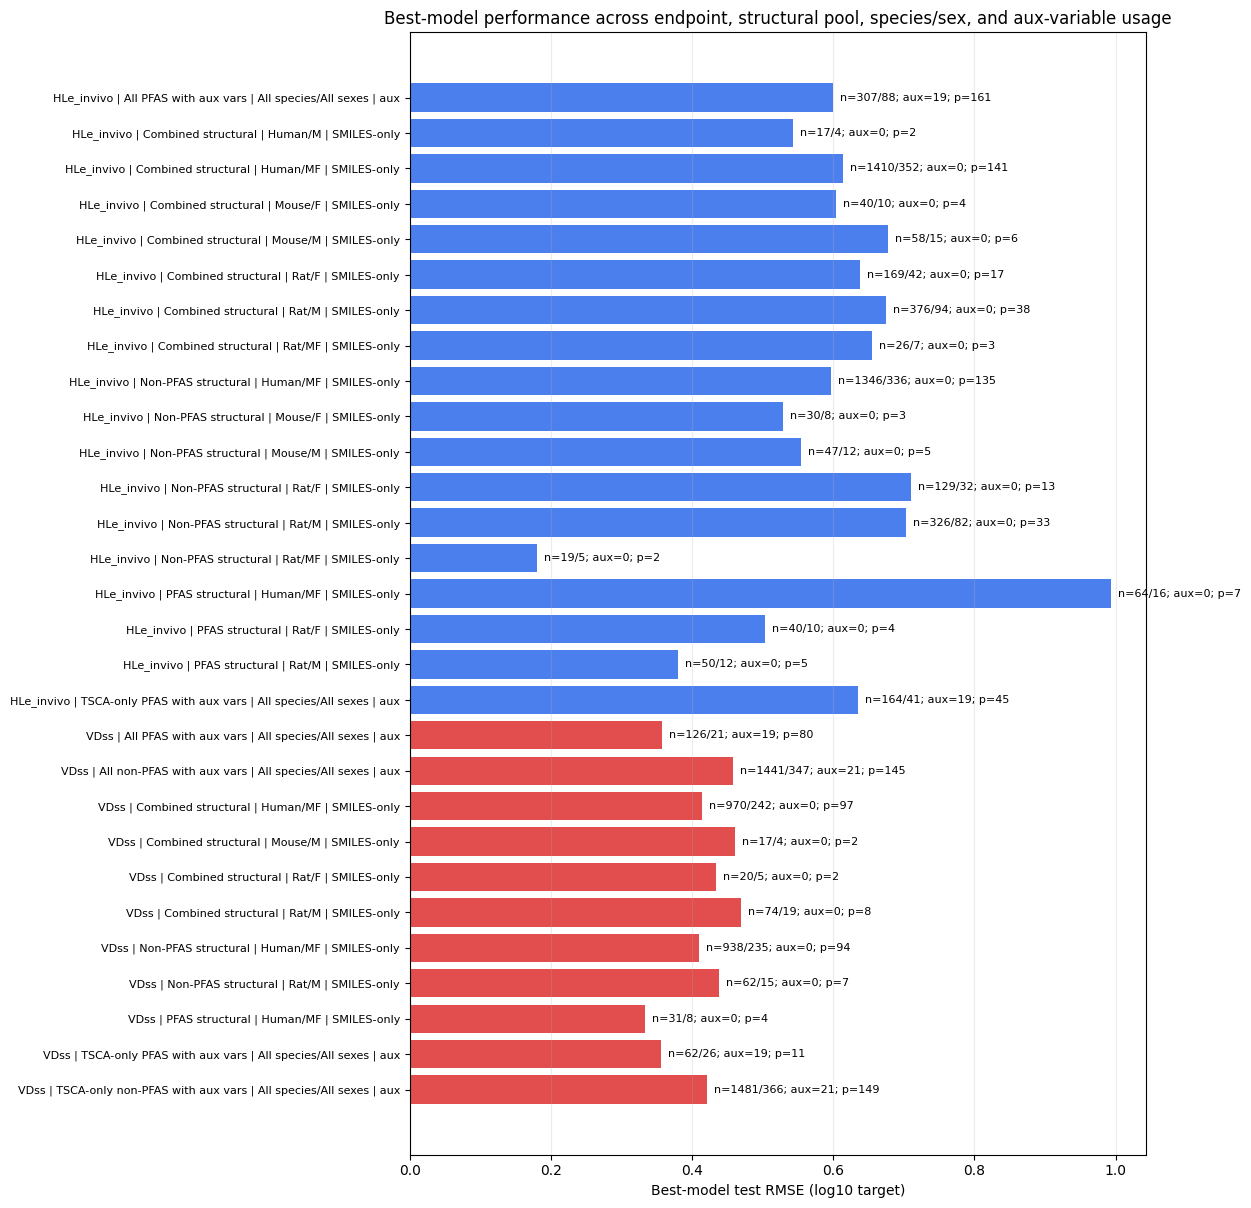

In [22]:
overview_cols = [
    'dataset_label', 'target_family', 'structural_pool', 'species', 'sex', 'model', 'workflow',
    'n_train', 'n_test', 'aux_vars_used', 'auxiliary_feature_count', 'adj_r2_feature_count',
    'test_rmse', 'test_mae', 'test_r2', 'has_scatter_predictions'
]
comparison_table = best_model_performance[[c for c in overview_cols if c in best_model_performance.columns]].copy()
if 'aux_vars_used' in comparison_table.columns:
    comparison_table['aux_vars_used'] = comparison_table['aux_vars_used'].fillna(False).astype(bool)
display(comparison_table)

plot_metric = 'test_rmse'
plot_overview = comparison_table.dropna(subset=[plot_metric]).copy()
if plot_overview.empty:
    raise ValueError('No numeric test RMSE values are available for dataset split comparison.')
plot_overview['aux_label'] = np.where(plot_overview.get('aux_vars_used', False), 'aux', 'SMILES-only')
plot_overview['display_label'] = (
    plot_overview['target_family'].astype(str) + ' | ' +
    plot_overview['structural_pool'].astype(str) + ' | ' +
    plot_overview['species'].astype(str) + '/' + plot_overview['sex'].astype(str) + ' | ' +
    plot_overview['aux_label'].astype(str)
)
plot_overview = plot_overview.sort_values(['target_family', 'structural_pool', 'species', 'sex', 'aux_vars_used'])
fig_height = max(4.5, 0.42 * len(plot_overview))
fig, ax = plt.subplots(figsize=(12.5, fig_height))
color_map = {'HLe_invivo': '#2563eb', 'VDss': '#dc2626'}
colors = plot_overview['target_family'].map(color_map).fillna('#6b7280')
y_pos = np.arange(len(plot_overview))
ax.barh(y_pos, plot_overview[plot_metric], color=colors, alpha=0.82)
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_overview['display_label'], fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('Best-model test RMSE (log10 target)')
ax.set_title('Best-model performance across endpoint, structural pool, species/sex, and aux-variable usage')
ax.grid(axis='x', alpha=0.25)
for y, (_, row) in zip(y_pos, plot_overview.iterrows()):
    aux_count = row.get('auxiliary_feature_count', 0)
    aux_count = 0 if pd.isna(aux_count) else int(aux_count)
    p_count = row.get('adj_r2_feature_count', np.nan)
    p_text = 'NA' if pd.isna(p_count) else str(int(p_count))
    ax.text(
        row[plot_metric],
        y,
        f"  n={int(row.get('n_train', 0))}/{int(row.get('n_test', 0))}; aux={aux_count}; p={p_text}",
        va='center',
        fontsize=8,
    )
fig.tight_layout()
plt.show()


## Endpoint-Level Subset Strategy Analysis

This section ranks each endpoint by held-out test RMSE, then compares dataset-combination strategies with the data-size and complexity context kept visible. The first diagnostic plots endpoint-level RMSE and R2 against training-set size, colored by whether auxiliary variables were used. Pooled auxiliary source sheets are labeled separately as TSCA-only PFAS, all PFAS structural, TSCA-only non-PFAS, or all non-PFAS structural; combined structural sheets mean PFAS structural plus non-PFAS structural only. The following species-matched diagnostics join best-model prediction rows back to workbook species/sex metadata and recalculate test metrics within each species so mixed all-species auxiliary datasets are compared on like endpoint/species slices; a final version repeats the same recalculation for PFAS chemicals only.


,target_family,dataset_label,structural_pool,species,sex,aux_vars_used,auxiliary_feature_count,n_train,n_test,n_total,...,test_mae,test_r2,cv_rmse,train_rmse,model,workflow,small_train_set,small_test_set,aux_feature_to_train_ratio,selected_feature_to_train_ratio
0,HLe_invivo,hle_invivo_nonpfas_rat_mf,Non-PFAS structural,Rat,MF,False,0,19,5,24,...,0.162335,0.640138,0.660169,0.384775,"Ensemble (OOF Stacking (RidgeCV, 5-fold))",ensemble,True,False,0.0,0.105263
1,VDss,vdss_human_mf,PFAS structural,Human,MF,False,0,31,8,39,...,0.290398,0.761635,0.319031,0.214320,Tabular CNN,conventional,False,False,0.0,0.129032


,target_family,structural_pool,aux_vars_used,completed_datasets,best_test_rmse,median_test_rmse,median_test_mae,median_test_r2,median_n_train,median_n_test,median_auxiliary_feature_count,median_selected_feature_count,median_aux_feature_to_train_ratio,median_selected_feature_to_train_ratio,small_test_sets
2,HLe_invivo,Non-PFAS structural,False,6,0.180465,0.575294,0.434864,0.342968,88.0,22.0,0.0,9.0,0.000000,0.101001,0
3,HLe_invivo,PFAS structural,False,3,0.380034,0.503661,0.396398,0.367395,50.0,12.0,0.0,5.0,0.000000,0.100000,0
1,HLe_invivo,Combined structural,False,7,0.542539,0.638598,0.486718,0.427112,58.0,15.0,0.0,6.0,0.000000,0.101064,1
0,HLe_invivo,All PFAS with aux vars,True,1,0.599007,0.599007,0.470415,0.708356,307.0,88.0,19.0,161.0,0.061889,0.524430,0
4,HLe_invivo,TSCA-only PFAS with aux vars,True,1,0.634530,0.634530,0.540503,0.845184,164.0,41.0,19.0,45.0,0.115854,0.274390,0
9,VDss,PFAS structural,False,1,0.333285,0.333285,0.290398,0.761635,31.0,8.0,0.0,4.0,0.000000,0.129032,0
10,VDss,TSCA-only PFAS with aux vars,True,1,0.355504,0.355504,0.273255,-0.102124,62.0,26.0,19.0,11.0,0.306452,0.177419,0
5,VDss,All PFAS with aux vars,True,1,0.356843,0.356843,0.283920,0.700259,126.0,21.0,19.0,80.0,0.150794,0.634921,0
8,VDss,Non-PFAS structural,False,2,0.410121,0.424257,0.322392,0.530870,500.0,125.0,0.0,50.5,0.000000,0.106558,0
7,VDss,Combined structural,False,4,0.413404,0.447302,0.363267,0.473304,47.0,12.0,0.0,5.0,0.000000,0.104054,1


,target_family,best_dataset_label,best_structural_pool,best_species,best_sex,best_aux_vars_used,best_auxiliary_feature_count,best_n_train,best_n_test,best_test_rmse,best_test_mae,best_test_r2,best_aux_minus_best_no_aux_rmse,evidence_note
0,HLe_invivo,hle_invivo_nonpfas_rat_mf,Non-PFAS structural,Rat,MF,False,0,19,5,0.180465,0.162335,0.640138,0.418542,SMILES-only subsetting currently has lower bes...
1,VDss,vdss_human_mf,PFAS structural,Human,MF,False,0,31,8,0.333285,0.290398,0.761635,0.022219,SMILES-only subsetting currently has lower bes...


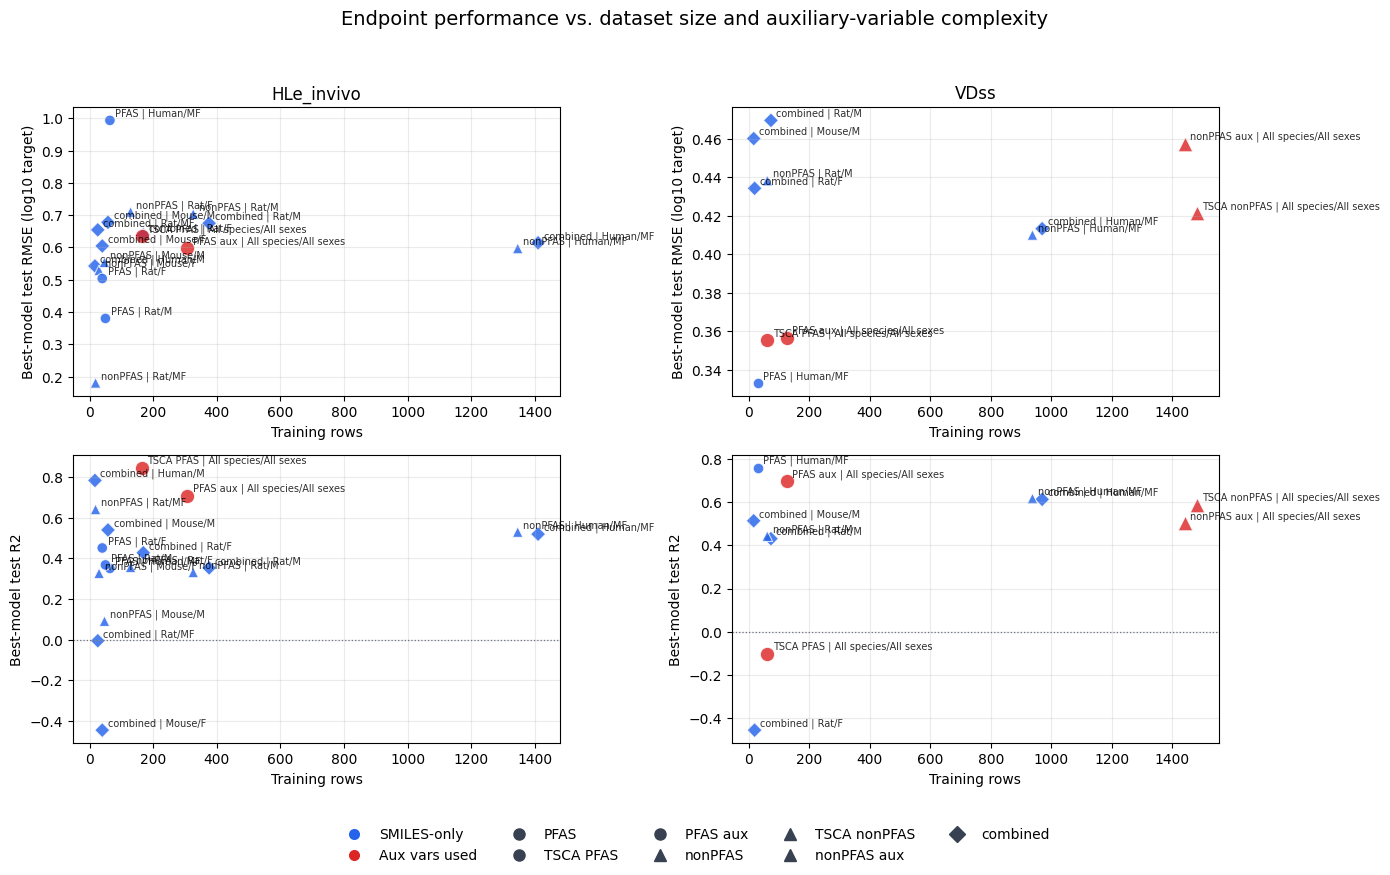

,view,target_family,eval_species,dataset_label,structural_pool,aux_vars_used,model_train_n,subgroup_train_n,test_n,pfas_test_n,test_rmse,test_mae,test_r2,test_sexes,model,workflow
0,All test chemicals,HLe_invivo,Human,HLe_invivo_pfas_tsca,TSCA-only PFAS with aux vars,True,164,35,11,11,0.374065,0.272520,0.876673,"F, M, MF",HistGradientBoosting,conventional
1,All test chemicals,HLe_invivo,Human,hle_invivo_struct_human_m,Combined structural,False,17,17,4,0,0.542539,0.447184,0.782589,M,Extra trees,conventional
2,All test chemicals,HLe_invivo,Human,hle_invivo_nonpfas_human_mf,Non-PFAS structural,False,1346,1346,336,0,0.596799,0.440833,0.528841,MF,CFA (Combinatorial Fusion),cfa
3,All test chemicals,HLe_invivo,Human,hle_invivo_struct_human_mf,Combined structural,False,1410,1410,352,18,0.614350,0.450620,0.518622,MF,MapLight CatBoost (Strict Parity),conventional
4,All test chemicals,HLe_invivo,Human,hle_invivo_pfas_struct,All PFAS with aux vars,True,307,115,30,30,0.630624,0.452895,0.717872,"F, M, MF",Random forest,conventional
5,All test chemicals,HLe_invivo,Human,hle_invivo_human_mf,PFAS structural,False,64,64,16,16,0.993509,0.750776,0.349978,MF,MapLight CatBoost (Strict Parity),conventional
6,All test chemicals,HLe_invivo,Monkey,HLe_invivo_pfas_tsca,TSCA-only PFAS with aux vars,True,164,21,2,2,0.309630,0.306958,-1242.694446,"F, M",HistGradientBoosting,conventional
7,All test chemicals,HLe_invivo,Monkey,hle_invivo_pfas_struct,All PFAS with aux vars,True,307,19,5,5,0.836793,0.728071,-4.256916,"F, M, MF",Random forest,conventional
8,All test chemicals,HLe_invivo,Mouse,hle_invivo_pfas_struct,All PFAS with aux vars,True,307,30,9,9,0.402775,0.350360,0.843668,"F, M",Random forest,conventional
9,All test chemicals,HLe_invivo,Mouse,hle_invivo_nonpfas_mouse_f,Non-PFAS structural,False,30,30,8,0,0.529049,0.417146,0.326033,F,Ensemble (Weighted average (inverse train RMSE)),ensemble


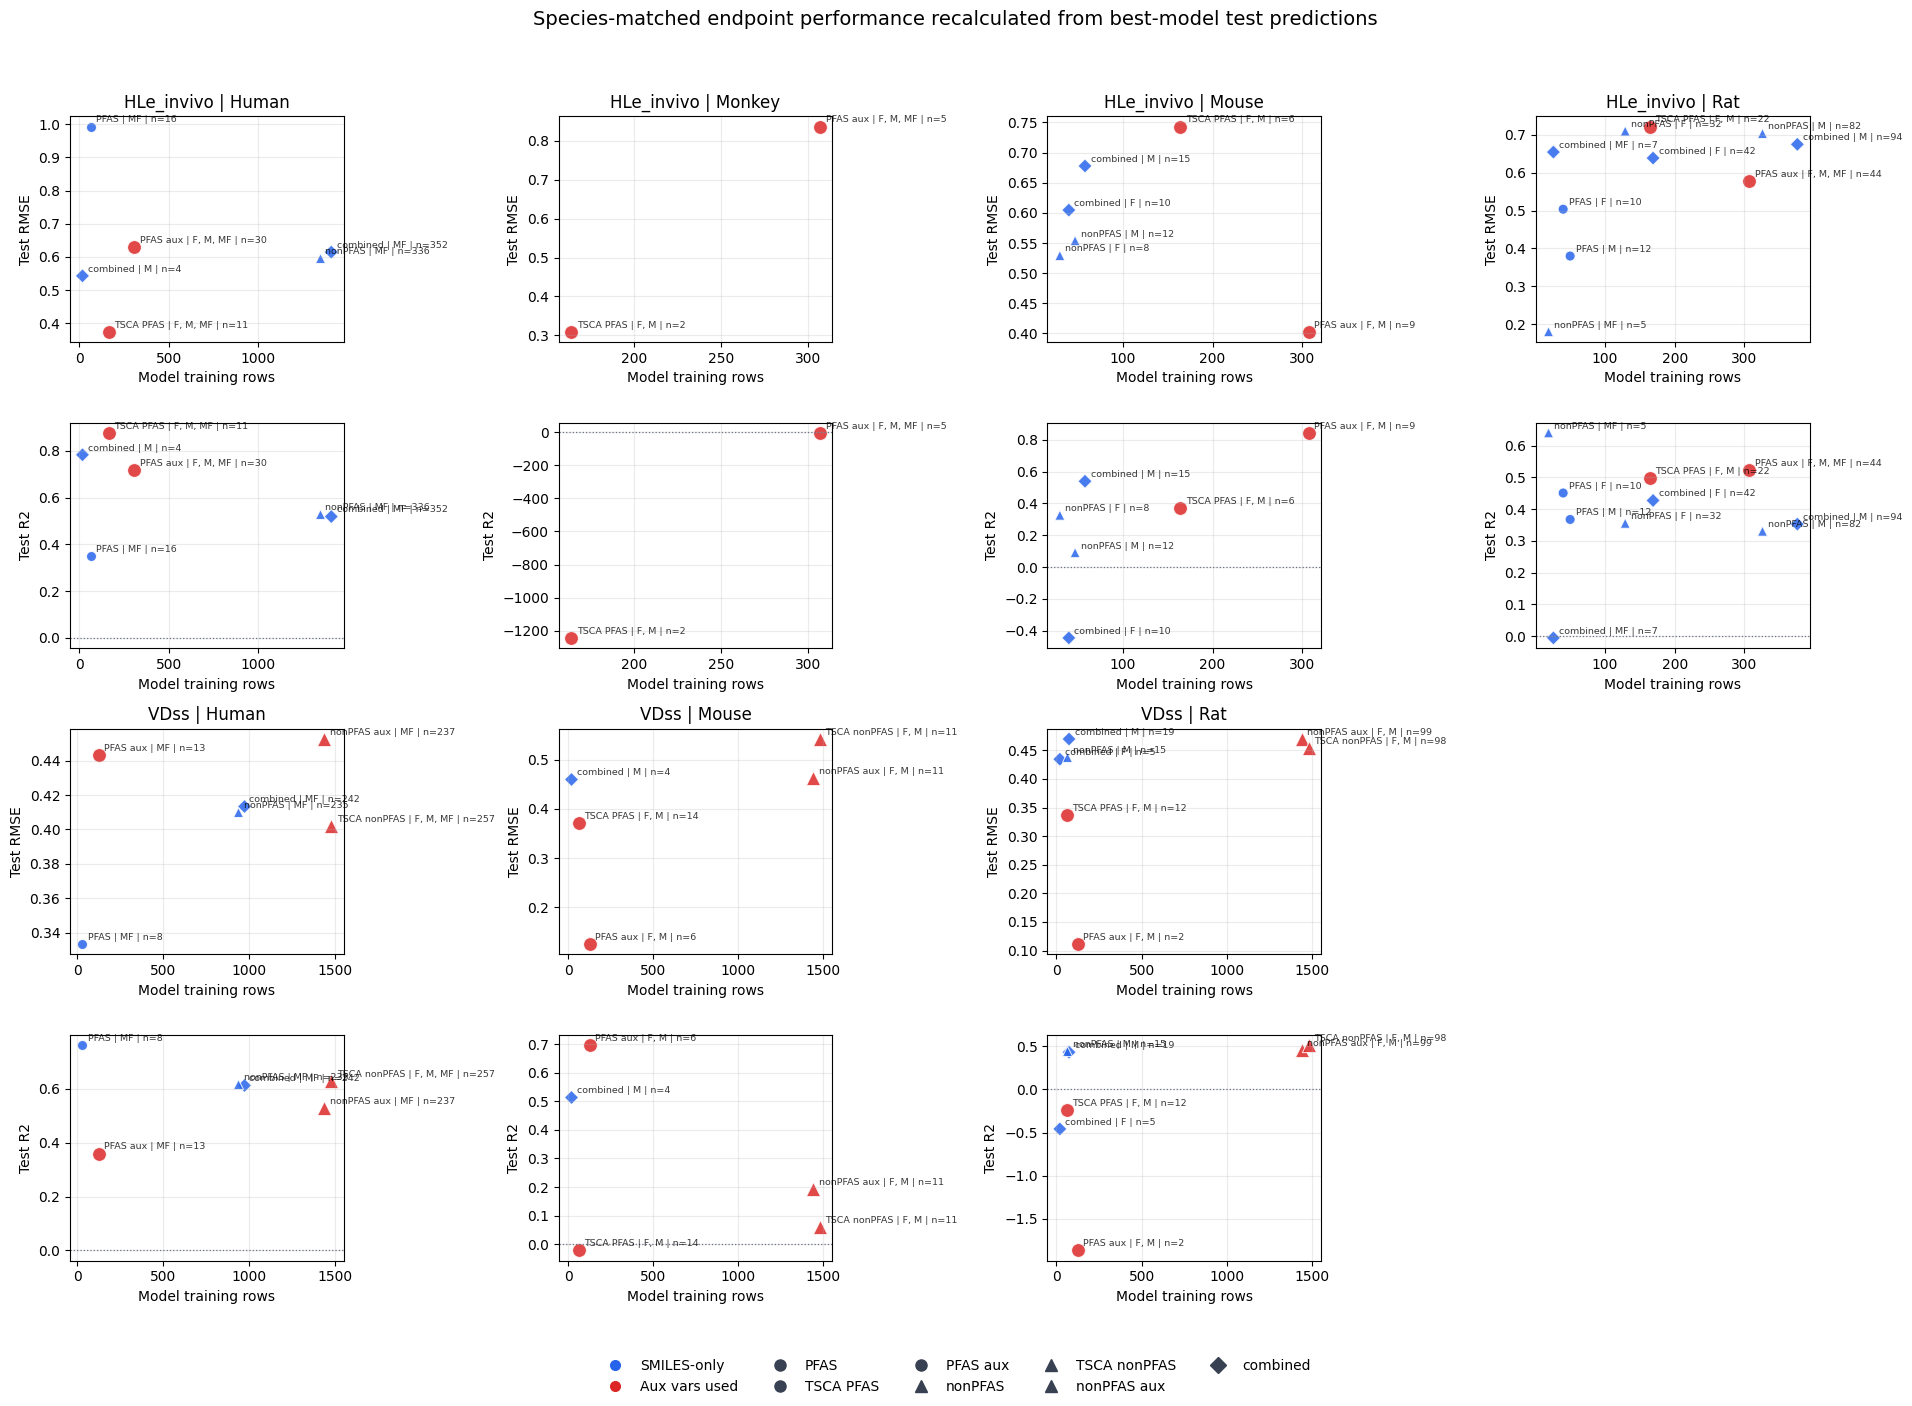

,view,target_family,eval_species,dataset_label,structural_pool,aux_vars_used,model_train_n,subgroup_train_n,test_n,pfas_test_n,test_rmse,test_mae,test_r2,test_sexes,model,workflow
0,PFAS test chemicals only,HLe_invivo,Human,HLe_invivo_pfas_tsca,TSCA-only PFAS with aux vars,True,164,35,11,11,0.374065,0.272520,0.876673,"F, M, MF",HistGradientBoosting,conventional
1,PFAS test chemicals only,HLe_invivo,Human,hle_invivo_pfas_struct,All PFAS with aux vars,True,307,115,30,30,0.630624,0.452895,0.717872,"F, M, MF",Random forest,conventional
2,PFAS test chemicals only,HLe_invivo,Human,hle_invivo_struct_human_mf,Combined structural,False,1410,51,18,18,0.691196,0.523503,-0.318068,MF,MapLight CatBoost (Strict Parity),conventional
3,PFAS test chemicals only,HLe_invivo,Human,hle_invivo_human_mf,PFAS structural,False,64,64,16,16,0.993509,0.750776,0.349978,MF,MapLight CatBoost (Strict Parity),conventional
4,PFAS test chemicals only,HLe_invivo,Monkey,HLe_invivo_pfas_tsca,TSCA-only PFAS with aux vars,True,164,21,2,2,0.309630,0.306958,-1242.694446,"F, M",HistGradientBoosting,conventional
5,PFAS test chemicals only,HLe_invivo,Monkey,hle_invivo_pfas_struct,All PFAS with aux vars,True,307,19,5,5,0.836793,0.728071,-4.256916,"F, M, MF",Random forest,conventional
6,PFAS test chemicals only,HLe_invivo,Mouse,hle_invivo_pfas_struct,All PFAS with aux vars,True,307,30,9,9,0.402775,0.350360,0.843668,"F, M",Random forest,conventional
7,PFAS test chemicals only,HLe_invivo,Mouse,HLe_invivo_pfas_tsca,TSCA-only PFAS with aux vars,True,164,29,6,6,0.743267,0.699193,0.368346,"F, M",HistGradientBoosting,conventional
8,PFAS test chemicals only,HLe_invivo,Rat,hle_invivo_struct_rat_mf,Combined structural,False,26,7,1,1,0.013428,0.013428,NaN,MF,"Chemprop v2 (AttentiveFP, ensemble=1)",Chemprop v2
9,PFAS test chemicals only,HLe_invivo,Rat,hle_invivo_rat_m,PFAS structural,False,50,50,12,12,0.380034,0.302978,0.367395,M,MapLight CatBoost (Strict Parity),conventional


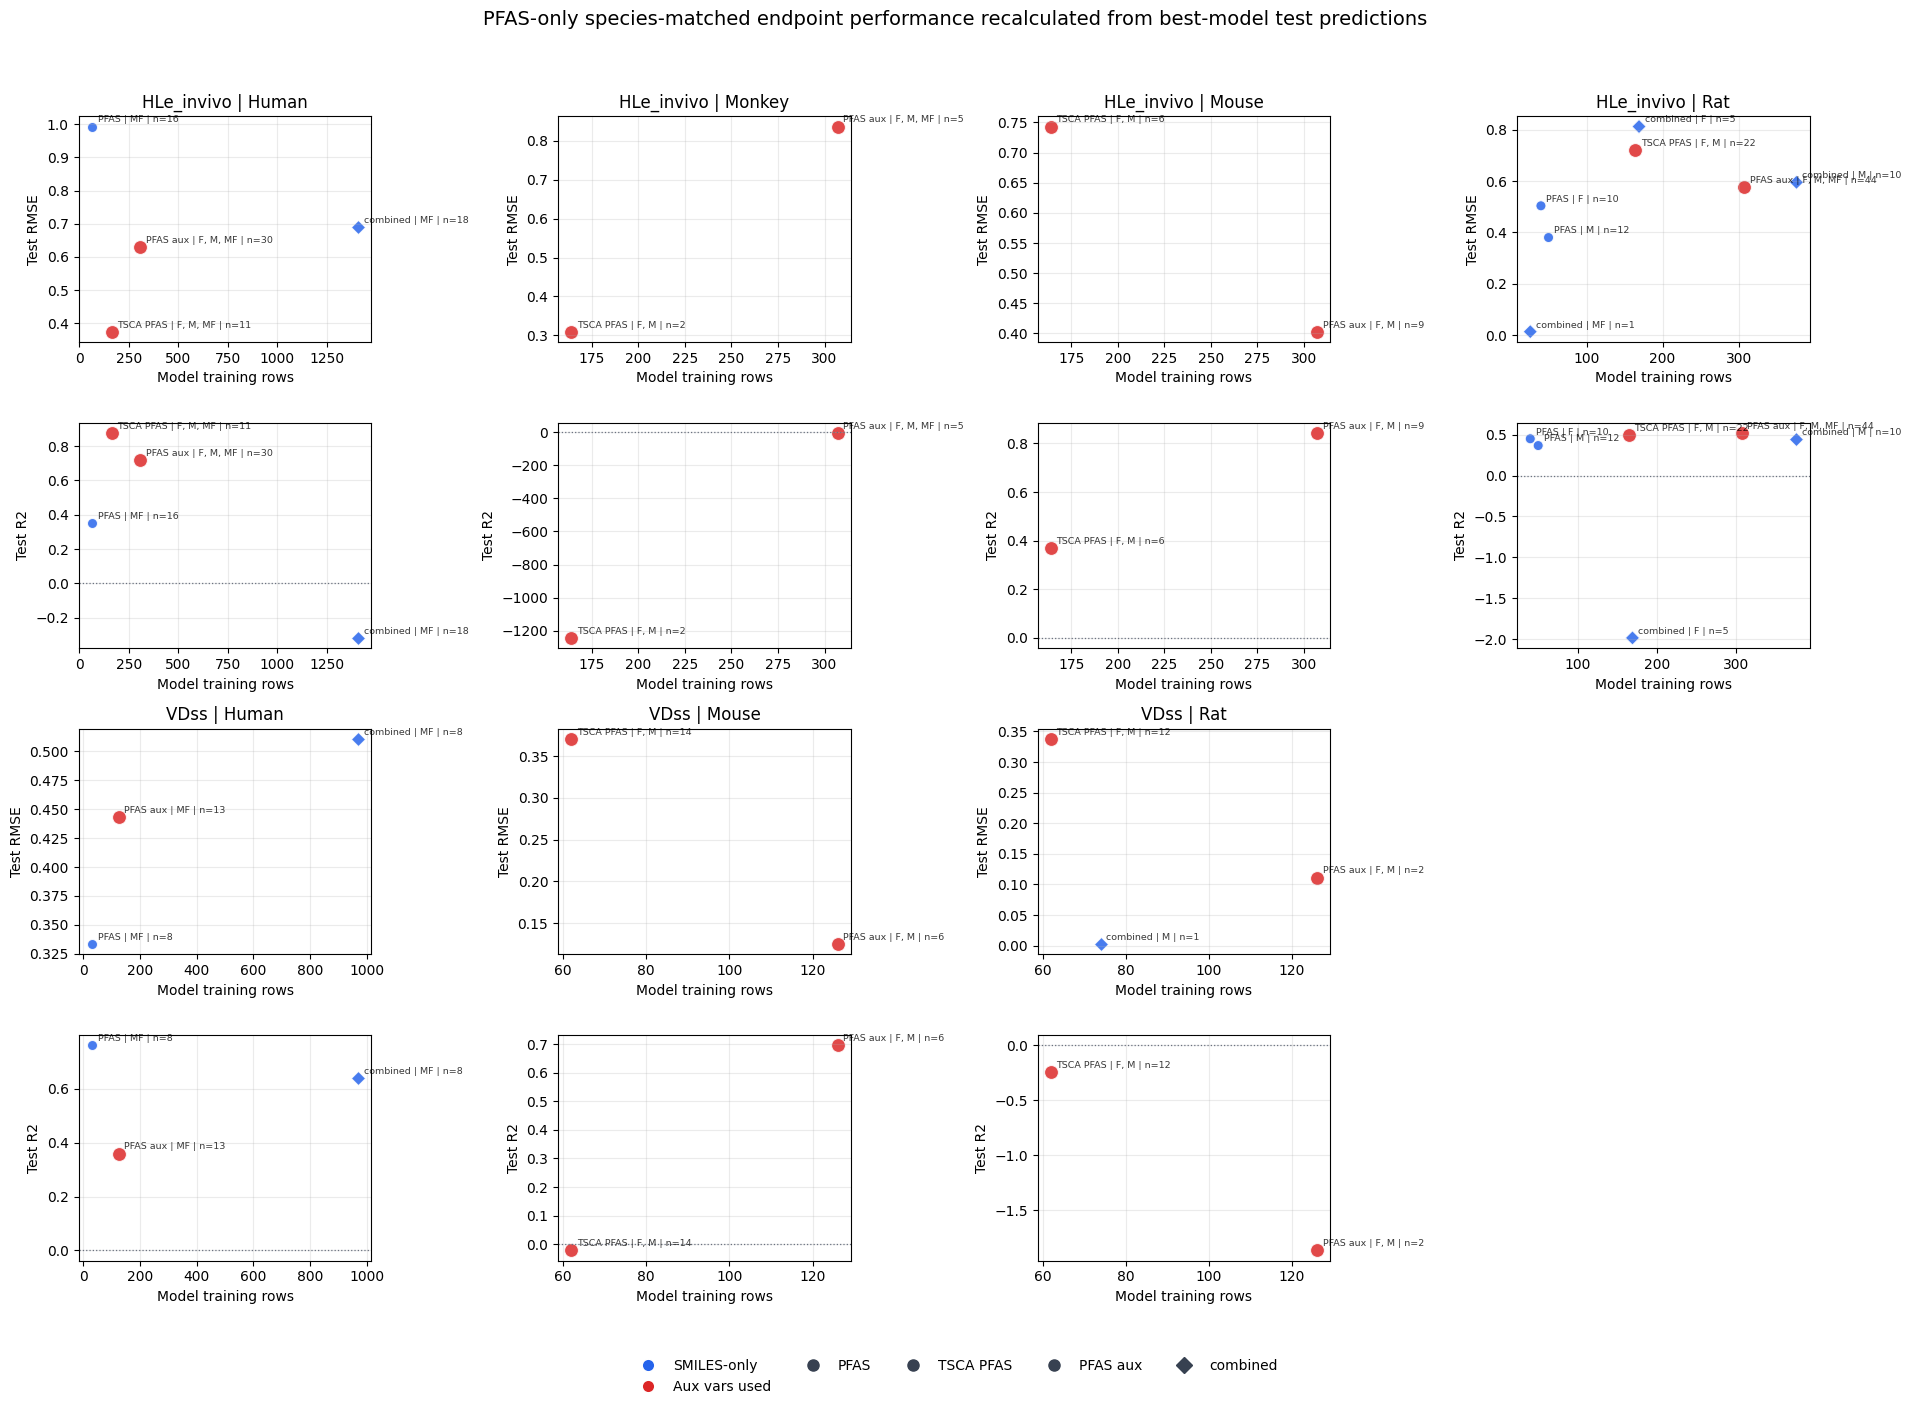

In [23]:
strategy = best_model_performance.copy()
for col in [
    'n_train', 'n_test', 'test_rmse', 'test_mae', 'test_r2', 'cv_rmse', 'train_rmse',
    'auxiliary_feature_count', 'adj_r2_feature_count', 'selected_feature_count'
]:
    if col in strategy.columns:
        strategy[col] = pd.to_numeric(strategy[col], errors='coerce')
strategy['n_total'] = strategy.get('n_train', 0).fillna(0) + strategy.get('n_test', 0).fillna(0)
strategy['aux_vars_used'] = strategy.get('aux_vars_used', False).fillna(False).astype(bool)
strategy['auxiliary_feature_count'] = strategy.get('auxiliary_feature_count', 0).fillna(0)
strategy['aux_feature_to_train_ratio'] = np.where(strategy['n_train'] > 0, strategy['auxiliary_feature_count'] / strategy['n_train'], np.nan)
strategy['selected_feature_to_train_ratio'] = np.where(strategy['n_train'] > 0, strategy['adj_r2_feature_count'] / strategy['n_train'], np.nan)
strategy['small_test_set'] = strategy['n_test'] < 5
strategy['small_train_set'] = strategy['n_train'] < 20
strategy['endpoint_rank_by_test_rmse'] = strategy.groupby('target_family')['test_rmse'].rank(method='min', ascending=True)

endpoint_sort_cols = ['target_family', 'test_rmse', 'test_mae', 'n_total']
endpoint_best_subset = (
    strategy.dropna(subset=['target_family', 'test_rmse'])
    .sort_values(endpoint_sort_cols, ascending=[True, True, True, False])
    .groupby('target_family', as_index=False)
    .first()
)
endpoint_cols = [
    'target_family', 'dataset_label', 'structural_pool', 'species', 'sex', 'aux_vars_used',
    'auxiliary_feature_count', 'n_train', 'n_test', 'n_total', 'test_rmse', 'test_mae', 'test_r2',
    'cv_rmse', 'train_rmse', 'model', 'workflow', 'small_train_set', 'small_test_set',
    'aux_feature_to_train_ratio', 'selected_feature_to_train_ratio'
]
endpoint_best_subset = endpoint_best_subset[[c for c in endpoint_cols if c in endpoint_best_subset.columns]]
display(endpoint_best_subset)

subset_strategy_diagnostics = (
    strategy.dropna(subset=['target_family', 'test_rmse'])
    .groupby(['target_family', 'structural_pool', 'aux_vars_used'], dropna=False)
    .agg(
        completed_datasets=('dataset_label', 'count'),
        best_test_rmse=('test_rmse', 'min'),
        median_test_rmse=('test_rmse', 'median'),
        median_test_mae=('test_mae', 'median'),
        median_test_r2=('test_r2', 'median'),
        median_n_train=('n_train', 'median'),
        median_n_test=('n_test', 'median'),
        median_auxiliary_feature_count=('auxiliary_feature_count', 'median'),
        median_selected_feature_count=('adj_r2_feature_count', 'median'),
        median_aux_feature_to_train_ratio=('aux_feature_to_train_ratio', 'median'),
        median_selected_feature_to_train_ratio=('selected_feature_to_train_ratio', 'median'),
        small_test_sets=('small_test_set', 'sum'),
    )
    .reset_index()
    .sort_values(['target_family', 'best_test_rmse', 'median_test_rmse'])
)
display(subset_strategy_diagnostics)

interpretation_rows = []
for endpoint, sub in strategy.dropna(subset=['target_family', 'test_rmse']).groupby('target_family'):
    sub = sub.sort_values(['test_rmse', 'test_mae', 'n_total'], ascending=[True, True, False])
    best = sub.iloc[0]
    best_aux = sub[sub['aux_vars_used']].sort_values(['test_rmse', 'test_mae']).head(1)
    best_no_aux = sub[~sub['aux_vars_used']].sort_values(['test_rmse', 'test_mae']).head(1)
    aux_delta = np.nan
    if not best_aux.empty and not best_no_aux.empty:
        aux_delta = float(best_aux.iloc[0]['test_rmse'] - best_no_aux.iloc[0]['test_rmse'])
    if pd.isna(aux_delta):
        note = 'Insufficient paired aux and SMILES-only completed runs for this endpoint.'
    elif aux_delta < -0.01:
        note = 'Auxiliary-variable pooling currently has lower best test RMSE than SMILES-only splits.'
    elif aux_delta > 0.01:
        note = 'SMILES-only subsetting currently has lower best test RMSE than auxiliary-variable pooling.'
    else:
        note = 'Best aux and SMILES-only test RMSE are similar at current precision.'
    interpretation_rows.append({
        'target_family': endpoint,
        'best_dataset_label': best.get('dataset_label', ''),
        'best_structural_pool': best.get('structural_pool', ''),
        'best_species': best.get('species', ''),
        'best_sex': best.get('sex', ''),
        'best_aux_vars_used': bool(best.get('aux_vars_used', False)),
        'best_auxiliary_feature_count': int(best.get('auxiliary_feature_count', 0) or 0),
        'best_n_train': int(best.get('n_train', 0) or 0),
        'best_n_test': int(best.get('n_test', 0) or 0),
        'best_test_rmse': best.get('test_rmse', np.nan),
        'best_test_mae': best.get('test_mae', np.nan),
        'best_test_r2': best.get('test_r2', np.nan),
        'best_aux_minus_best_no_aux_rmse': aux_delta,
        'evidence_note': note,
    })
endpoint_strategy_interpretation = pd.DataFrame(interpretation_rows)
display(endpoint_strategy_interpretation)

from matplotlib.lines import Line2D

AUX_COLORS = {False: '#2563eb', True: '#dc2626'}
AUX_LABELS = {False: 'SMILES-only', True: 'Aux vars used'}
POOL_MARKERS = {
    'PFAS structural': 'o',
    'TSCA-only PFAS with aux vars': 'o',
    'All PFAS with aux vars': 'o',
    'Non-PFAS structural': '^',
    'TSCA-only non-PFAS with aux vars': '^',
    'All non-PFAS with aux vars': '^',
    'Combined structural': 'D',
    'PFAS + non-PFAS structural analogs': 'D',
}
POOL_SHORT = {
    'PFAS structural': 'PFAS',
    'TSCA-only PFAS with aux vars': 'TSCA PFAS',
    'All PFAS with aux vars': 'PFAS aux',
    'Non-PFAS structural': 'nonPFAS',
    'TSCA-only non-PFAS with aux vars': 'TSCA nonPFAS',
    'All non-PFAS with aux vars': 'nonPFAS aux',
    'Combined structural': 'combined',
    'PFAS + non-PFAS structural analogs': 'combined',
}
SPECIES_ORDER = ['Human', 'Monkey', 'Mouse', 'Rat', 'All species', 'Unknown']


def _marker_for_pool(pool):
    return POOL_MARKERS.get(str(pool), 's')


def _short_pool(pool):
    return POOL_SHORT.get(str(pool), str(pool))


def _safe_bool(value):
    if pd.isna(value):
        return False
    if isinstance(value, str):
        return value.strip().lower() in {'1', 'true', 'yes', 'y'}
    return bool(value)


def _format_species_token(token):
    text = str(token or '').strip().replace('_', ' ')
    if not text or text.lower() in {'nan', 'none', '<na>'}:
        return 'Unknown'
    return text.title()


def _format_sex_token(token):
    text = str(token or '').strip().replace('_', ' ')
    if not text or text.lower() in {'nan', 'none', '<na>'}:
        return 'Unknown'
    mapping = {
        'f': 'F',
        'm': 'M',
        'mf': 'MF',
        'not available': 'Not available',
        'not reported': 'Not reported',
        'all sexes': 'All sexes',
        'pooled': 'pooled',
    }
    return mapping.get(text.lower(), text.upper() if len(text) <= 3 else text.title())


def _one_hot_label(df, prefix, default_value, formatter):
    cols = [col for col in df.columns if str(col).startswith(prefix)]
    default = pd.Series(default_value, index=df.index, dtype=object)
    if not cols:
        return default
    values = df[cols].apply(pd.to_numeric, errors='coerce').fillna(0)
    max_values = values.max(axis=1)
    labels = values.idxmax(axis=1).astype(str).str.replace(prefix, '', regex=False).map(formatter)
    return labels.where(max_values > 0, default)


def _resolve_workbook_path():
    candidates = []
    configured = str(run_config.get('pfas_aux_workbook', '') or '').strip()
    if configured:
        configured_path = Path(configured)
        candidates.append(configured_path if configured_path.is_absolute() else ROOT / configured_path)
    candidates.append(ROOT / 'data' / 'modeling_datasets_aux_features.xlsx')
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return None


def _build_workbook_row_annotations(workbook_path):
    if workbook_path is None or not workbook_path.exists():
        return pd.DataFrame(), {}
    frames = []
    with pd.ExcelFile(workbook_path) as xl:
        for sheet in list(xl.sheet_names):
            if sheet.lower() == 'manifest':
                continue
            df = pd.read_excel(xl, sheet_name=sheet)
            if df.empty or 'QSAR_READY_SMILES' not in df.columns or 'TARGET_log10' not in df.columns:
                continue
            subset_default = ''
            if 'smiles_subset' in df.columns:
                non_missing_subset = df['smiles_subset'].dropna().astype(str).str.strip()
                subset_default = non_missing_subset.iloc[0] if not non_missing_subset.empty else ''
            parsed = parse_workbook_dataset_label(sheet, subset_default)
            ann = pd.DataFrame({
                'sheet': sheet,
                'sheet_key': sheet.lower(),
                'row_index_key': pd.Series(df.index, index=df.index).astype(int).astype(str),
                'split_key': df.get('split', pd.Series('', index=df.index)).fillna('').astype(str).str.lower(),
                'workbook_smiles': df['QSAR_READY_SMILES'].fillna('').astype(str),
                'workbook_target': pd.to_numeric(df['TARGET_log10'], errors='coerce'),
                'target_family': parsed.get('target_family', ''),
                'row_smiles_subset': df.get('smiles_subset', pd.Series('', index=df.index)).fillna('').astype(str),
            }, index=df.index)
            ann['eval_species'] = _one_hot_label(df, 'species_', parsed.get('species', 'Unknown'), _format_species_token)
            ann['eval_sex'] = _one_hot_label(df, 'sex_', parsed.get('sex', 'Unknown'), _format_sex_token)
            subset_text = ann['row_smiles_subset'].str.lower()
            ann['is_pfas_chemical'] = pd.Series(pd.NA, index=ann.index, dtype='boolean')
            explicit_nonpfas = subset_text.str.contains('nonpfas|non_pfas', regex=True, na=False)
            explicit_pfas = subset_text.str.contains('pfas', na=False) & ~explicit_nonpfas
            ann.loc[explicit_pfas, 'is_pfas_chemical'] = True
            ann.loc[explicit_nonpfas, 'is_pfas_chemical'] = False
            frames.append(ann)
    if not frames:
        return pd.DataFrame(), {}
    annotations = pd.concat(frames, ignore_index=True)
    pfas_smiles_by_target = (
        annotations[annotations['is_pfas_chemical'].eq(True)]
        .groupby('target_family')['workbook_smiles']
        .agg(lambda values: set(values.dropna().astype(str)))
        .to_dict()
    )
    missing_flag = annotations['is_pfas_chemical'].isna()
    if missing_flag.any():
        inferred = []
        for _, row in annotations.loc[missing_flag].iterrows():
            inferred.append(row['workbook_smiles'] in pfas_smiles_by_target.get(row['target_family'], set()))
        annotations.loc[missing_flag, 'is_pfas_chemical'] = inferred
    annotations['is_pfas_chemical'] = annotations['is_pfas_chemical'].fillna(False).astype(bool)
    annotations['split_seq'] = annotations.groupby(['sheet_key', 'split_key']).cumcount()
    annotations['species_sex_eval'] = annotations['eval_species'].astype(str) + ' / ' + annotations['eval_sex'].astype(str)
    return annotations, pfas_smiles_by_target


def _row_index_key(series):
    numeric = pd.to_numeric(series, errors='coerce')
    out = pd.Series('', index=series.index, dtype=object)
    mask = numeric.notna()
    out.loc[mask] = numeric.loc[mask].round().astype(int).astype(str)
    return out


def _enrich_predictions_with_subgroups(prediction_rows, workbook_annotations, pfas_smiles_by_target):
    pred = prediction_rows.copy().reset_index(drop=True)
    pred['_row_id'] = np.arange(len(pred))
    if 'sheet' in pred.columns:
        sheet_guess = pred['sheet'].fillna('').astype(str)
    else:
        sheet_guess = pd.Series('', index=pred.index, dtype=object)
    label_guess = pred.get('dataset_label', pred.get('dataset', pd.Series('', index=pred.index))).fillna('').astype(str)
    pred['sheet_for_join'] = sheet_guess.where(sheet_guess.str.strip().ne(''), label_guess)
    pred['sheet_key'] = pred['sheet_for_join'].str.lower()
    pred['split_key'] = pred.get('plot_split', pred.get('split', pd.Series('', index=pred.index))).fillna('').astype(str).str.lower()
    pred['row_index_key'] = _row_index_key(pred['row_index']) if 'row_index' in pred.columns else ''
    pred['split_seq'] = pred.groupby(['sheet_key', 'model', 'split_key']).cumcount()

    ann_cols = [
        'sheet_key', 'row_index_key', 'split_key', 'split_seq', 'eval_species', 'eval_sex',
        'species_sex_eval', 'is_pfas_chemical', 'row_smiles_subset'
    ]
    if workbook_annotations.empty:
        enriched = pred.copy()
        for col in ann_cols[4:]:
            enriched[col] = np.nan
    else:
        ann_row = workbook_annotations[[c for c in ann_cols if c in workbook_annotations.columns]].copy()
        ann_row = ann_row.rename(columns={
            'eval_species': 'ann_eval_species',
            'eval_sex': 'ann_eval_sex',
            'species_sex_eval': 'ann_species_sex_eval',
            'is_pfas_chemical': 'ann_is_pfas_chemical',
            'row_smiles_subset': 'ann_row_smiles_subset',
        })
        enriched = pred.merge(
            ann_row.drop(columns=['split_key', 'split_seq'], errors='ignore'),
            on=['sheet_key', 'row_index_key'],
            how='left',
        )
        missing = enriched['ann_eval_species'].isna()
        if missing.any():
            ann_seq = ann_row.drop(columns=['row_index_key'], errors='ignore')
            fallback = pred.loc[missing, ['_row_id', 'sheet_key', 'split_key', 'split_seq']].merge(
                ann_seq,
                on=['sheet_key', 'split_key', 'split_seq'],
                how='left',
            ).set_index('_row_id')
            for col in ['ann_eval_species', 'ann_eval_sex', 'ann_species_sex_eval', 'ann_is_pfas_chemical', 'ann_row_smiles_subset']:
                enriched.loc[missing, col] = enriched.loc[missing, '_row_id'].map(fallback[col])

    enriched['eval_species'] = enriched.get('ann_eval_species', pd.Series(np.nan, index=enriched.index)).fillna(enriched.get('species', 'Unknown')).map(_format_species_token)
    enriched['eval_sex'] = enriched.get('ann_eval_sex', pd.Series(np.nan, index=enriched.index)).fillna(enriched.get('sex', 'Unknown')).map(_format_sex_token)
    enriched['species_sex_eval'] = enriched['eval_species'].astype(str) + ' / ' + enriched['eval_sex'].astype(str)
    inferred_pfas = enriched.get('ann_is_pfas_chemical', pd.Series(np.nan, index=enriched.index))
    enriched['is_pfas_chemical'] = inferred_pfas.astype('boolean') if hasattr(inferred_pfas, 'astype') else inferred_pfas
    missing_pfas = enriched['is_pfas_chemical'].isna()
    if missing_pfas.any():
        structural_pool = enriched.get('structural_pool', pd.Series('', index=enriched.index)).astype(str)
        enriched.loc[missing_pfas & structural_pool.eq('PFAS structural'), 'is_pfas_chemical'] = True
        enriched.loc[missing_pfas & structural_pool.eq('Non-PFAS structural'), 'is_pfas_chemical'] = False
    missing_pfas = enriched['is_pfas_chemical'].isna()
    if missing_pfas.any():
        smiles = enriched.get('smiles', pd.Series('', index=enriched.index)).fillna('').astype(str)
        for idx in enriched.loc[missing_pfas].index:
            target = enriched.at[idx, 'target_family']
            enriched.at[idx, 'is_pfas_chemical'] = smiles.at[idx] in pfas_smiles_by_target.get(target, set())
    enriched['is_pfas_chemical'] = enriched['is_pfas_chemical'].fillna(False).astype(bool)
    return enriched


def _compute_species_test_performance(enriched_predictions, pfas_only=False):
    rows = enriched_predictions.copy()
    rows['observed'] = pd.to_numeric(rows['observed'], errors='coerce')
    rows['predicted'] = pd.to_numeric(rows['predicted'], errors='coerce')
    rows = rows.dropna(subset=['observed', 'predicted', 'target_family', 'eval_species'])
    if pfas_only:
        rows = rows[rows['is_pfas_chemical'].astype(bool)].copy()
    train_rows = rows[rows['plot_split'].eq('Train')].copy()
    test_rows = rows[rows['plot_split'].eq('Test')].copy()
    train_counts = train_rows.groupby(['dataset', 'model', 'eval_species']).size().rename('subgroup_train_n')
    records = []
    group_keys = ['dataset', 'model', 'target_family', 'eval_species']
    for keys, sub in test_rows.groupby(group_keys, dropna=False):
        dataset, model, target_family, eval_species = keys
        first = sub.iloc[0]
        subgroup_train_n = int(train_counts.get((dataset, model, eval_species), 0))
        test_sexes = ', '.join(sorted(set(str(value) for value in sub['eval_sex'].dropna())))
        n_test = int(len(sub))
        records.append({
            'view': 'PFAS test chemicals only' if pfas_only else 'All test chemicals',
            'dataset': dataset,
            'dataset_label': first.get('dataset_label', dataset),
            'target_family': target_family,
            'eval_species': eval_species,
            'test_sexes': test_sexes,
            'model': model,
            'workflow': first.get('workflow', ''),
            'structural_pool': first.get('structural_pool', ''),
            'aux_vars_used': _safe_bool(first.get('aux_vars_used', False)),
            'auxiliary_feature_count': int(first.get('auxiliary_feature_count', 0) or 0),
            'model_train_n': int(first.get('n_train', 0) or 0),
            'model_test_n': int(first.get('n_test', 0) or 0),
            'subgroup_train_n': subgroup_train_n,
            'test_n': n_test,
            'test_rmse': _rmse(sub['observed'], sub['predicted']),
            'test_mae': _mae(sub['observed'], sub['predicted']),
            'test_r2': _r2_score(sub['observed'], sub['predicted']),
            'pfas_test_n': int(sub['is_pfas_chemical'].astype(bool).sum()),
        })
    out = pd.DataFrame(records)
    if not out.empty:
        out['aux_label'] = np.where(out['aux_vars_used'], AUX_LABELS[True], AUX_LABELS[False])
        out['pool_short'] = out['structural_pool'].map(POOL_SHORT).fillna(out['structural_pool'])
        out['plot_label'] = out['pool_short'].astype(str) + ' | ' + out['test_sexes'].astype(str) + ' | n=' + out['test_n'].astype(str)
        sort_species = {name: i for i, name in enumerate(SPECIES_ORDER)}
        out['species_sort'] = out['eval_species'].map(sort_species).fillna(50)
        out = out.sort_values(['target_family', 'species_sort', 'eval_species', 'test_rmse', 'dataset_label']).reset_index(drop=True)
    return out


def _plot_metric_pair_by_endpoint(data, title):
    plot_data = data.dropna(subset=['n_train']).copy()
    if plot_data.empty:
        raise ValueError('No rows with numeric n_train values are available for endpoint performance plotting.')
    endpoints = list(plot_data['target_family'].dropna().unique())
    metrics_to_plot = [
        ('test_rmse', 'Best-model test RMSE (log10 target)'),
        ('test_r2', 'Best-model test R2'),
    ]
    fig, axes = plt.subplots(len(metrics_to_plot), len(endpoints), figsize=(7.0 * len(endpoints), 8.8), squeeze=False)
    for col_idx, endpoint in enumerate(endpoints):
        endpoint_data = plot_data[plot_data['target_family'].eq(endpoint)].copy()
        for row_idx, (metric, ylabel) in enumerate(metrics_to_plot):
            ax = axes[row_idx, col_idx]
            metric_data = endpoint_data.dropna(subset=[metric])
            for aux_used in [False, True]:
                aux_data = metric_data[metric_data['aux_vars_used'].eq(aux_used)]
                for pool, pool_data in aux_data.groupby('structural_pool', dropna=False):
                    if pool_data.empty:
                        continue
                    sizes = 58 + pool_data['auxiliary_feature_count'].fillna(0).clip(lower=0) * 2.5
                    ax.scatter(
                        pool_data['n_train'],
                        pool_data[metric],
                        s=sizes,
                        color=AUX_COLORS[aux_used],
                        marker=_marker_for_pool(pool),
                        alpha=0.82,
                        edgecolor='white',
                        linewidth=0.75,
                    )
                    for _, point in pool_data.iterrows():
                        point_label = f"{_short_pool(point.get('structural_pool', ''))} | {point.get('species', '')}/{point.get('sex', '')}"
                        ax.annotate(
                            point_label,
                            (point['n_train'], point[metric]),
                            xytext=(4, 3),
                            textcoords='offset points',
                            fontsize=7,
                            alpha=0.82,
                        )
            ax.set_title(endpoint if row_idx == 0 else '')
            ax.set_xlabel('Training rows')
            ax.set_ylabel(ylabel)
            ax.grid(True, alpha=0.25)
            if metric == 'test_r2':
                ax.axhline(0, color='#6b7280', linewidth=0.9, linestyle=':')
    aux_handles = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=AUX_COLORS[value], markeredgecolor='white', markersize=9, label=label)
        for value, label in AUX_LABELS.items()
    ]
    pool_handles = [
        Line2D([0], [0], marker=marker, color='#374151', linestyle='None', markersize=8, label=_short_pool(pool))
        for pool, marker in POOL_MARKERS.items()
        if pool in set(plot_data['structural_pool'].dropna())
    ]
    fig.legend(handles=aux_handles + pool_handles, loc='lower center', ncol=min(5, len(aux_handles + pool_handles)), frameon=False)
    fig.suptitle(title, y=0.98, fontsize=14)
    fig.tight_layout(rect=[0, 0.08, 1, 0.95])
    plt.show()


def _plot_species_matched_facets(metric_df, title):
    plot_data = metric_df.copy()
    plot_data = plot_data[plot_data['test_n'] > 0].dropna(subset=['target_family', 'eval_species', 'model_train_n'])
    if plot_data.empty:
        print(f'No species-matched rows available for: {title}')
        return
    facets = (
        plot_data[['target_family', 'eval_species', 'species_sort']]
        .drop_duplicates()
        .sort_values(['target_family', 'species_sort', 'eval_species'])
        .reset_index(drop=True)
    )
    ncols = min(4, max(1, len(facets)))
    facet_blocks = int(math.ceil(len(facets) / ncols))
    metrics_to_plot = [('test_rmse', 'Test RMSE'), ('test_r2', 'Test R2')]
    fig, axes = plt.subplots(facet_blocks * len(metrics_to_plot), ncols, figsize=(4.8 * ncols, 3.5 * facet_blocks * len(metrics_to_plot)), squeeze=False)
    for facet_idx, facet in facets.iterrows():
        block = facet_idx // ncols
        col = facet_idx % ncols
        sub = plot_data[
            plot_data['target_family'].eq(facet['target_family'])
            & plot_data['eval_species'].eq(facet['eval_species'])
        ].copy()
        for metric_idx, (metric, ylabel) in enumerate(metrics_to_plot):
            ax = axes[block * len(metrics_to_plot) + metric_idx, col]
            metric_sub = sub.dropna(subset=[metric])
            for aux_used in [False, True]:
                aux_sub = metric_sub[metric_sub['aux_vars_used'].eq(aux_used)]
                for pool, pool_sub in aux_sub.groupby('structural_pool', dropna=False):
                    if pool_sub.empty:
                        continue
                    sizes = 52 + pool_sub['auxiliary_feature_count'].fillna(0).clip(lower=0) * 2.5
                    ax.scatter(
                        pool_sub['model_train_n'],
                        pool_sub[metric],
                        s=sizes,
                        color=AUX_COLORS[aux_used],
                        marker=_marker_for_pool(pool),
                        alpha=0.84,
                        edgecolor='white',
                        linewidth=0.75,
                    )
                    for _, point in pool_sub.iterrows():
                        ax.annotate(
                            str(point.get('plot_label', '')),
                            (point['model_train_n'], point[metric]),
                            xytext=(4, 3),
                            textcoords='offset points',
                            fontsize=6.8,
                            alpha=0.78,
                        )
            ax.set_title(f"{facet['target_family']} | {facet['eval_species']}" if metric_idx == 0 else '')
            ax.set_xlabel('Model training rows')
            ax.set_ylabel(ylabel)
            ax.grid(True, alpha=0.25)
            if metric == 'test_r2':
                ax.axhline(0, color='#6b7280', linewidth=0.9, linestyle=':')
    for empty_idx in range(len(facets), facet_blocks * ncols):
        block = empty_idx // ncols
        col = empty_idx % ncols
        for metric_idx in range(len(metrics_to_plot)):
            axes[block * len(metrics_to_plot) + metric_idx, col].axis('off')
    aux_handles = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=AUX_COLORS[value], markeredgecolor='white', markersize=9, label=label)
        for value, label in AUX_LABELS.items()
    ]
    pool_handles = [
        Line2D([0], [0], marker=marker, color='#374151', linestyle='None', markersize=8, label=_short_pool(pool))
        for pool, marker in POOL_MARKERS.items()
        if pool in set(plot_data['structural_pool'].dropna())
    ]
    fig.legend(handles=aux_handles + pool_handles, loc='lower center', ncol=min(5, len(aux_handles + pool_handles)), frameon=False)
    fig.suptitle(title, y=0.995, fontsize=14)
    fig.tight_layout(rect=[0, 0.06, 1, 0.97])
    plt.show()


plot_strategy = strategy.dropna(subset=['n_train']).copy()
plot_strategy['aux_vars_used'] = plot_strategy['aux_vars_used'].astype(bool)
_plot_metric_pair_by_endpoint(
    plot_strategy,
    'Endpoint performance vs. dataset size and auxiliary-variable complexity',
)

workbook_path = _resolve_workbook_path()
workbook_annotations, pfas_smiles_by_target = _build_workbook_row_annotations(workbook_path)
plot_df = pd.concat(plot_parts, ignore_index=True) if plot_parts else pd.DataFrame()
if plot_df.empty:
    raise ValueError('No train/test prediction rows found for best models or fallback plotted models.')
plot_df['observed'] = pd.to_numeric(plot_df['observed'], errors='coerce')
plot_df['predicted'] = pd.to_numeric(plot_df['predicted'], errors='coerce')
plot_df = plot_df.dropna(subset=['observed', 'predicted', 'dataset_label', 'target_family'])
if plot_df.empty:
    raise ValueError('Best-model prediction rows were found, but none had numeric observed/predicted values.')
plot_df_for_subgroups = plot_df.copy()
lookup_cols = [
    'dataset', 'scatter_model', 'n_train', 'n_test', 'aux_vars_used', 'auxiliary_feature_count',
    'structural_pool', 'target_family', 'dataset_label'
]
panel_lookup = best_model_performance[[c for c in lookup_cols if c in best_model_performance.columns]].copy()
panel_lookup = panel_lookup.rename(columns={'scatter_model': 'model', 'n_train': 'model_train_n_lookup', 'n_test': 'model_test_n_lookup'})
plot_df_for_subgroups = plot_df_for_subgroups.merge(
    panel_lookup,
    on=['dataset', 'model'],
    how='left',
    suffixes=('', '_panel'),
)
for col, lookup_col in [('n_train', 'model_train_n_lookup'), ('n_test', 'model_test_n_lookup')]:
    if col not in plot_df_for_subgroups.columns:
        plot_df_for_subgroups[col] = np.nan
    if lookup_col in plot_df_for_subgroups.columns:
        plot_df_for_subgroups[col] = pd.to_numeric(plot_df_for_subgroups[col], errors='coerce').fillna(pd.to_numeric(plot_df_for_subgroups[lookup_col], errors='coerce'))
for col in ['aux_vars_used', 'auxiliary_feature_count', 'structural_pool', 'target_family', 'dataset_label']:
    panel_col = f'{col}_panel'
    if panel_col in plot_df_for_subgroups.columns:
        plot_df_for_subgroups[col] = plot_df_for_subgroups[col].where(plot_df_for_subgroups[col].notna(), plot_df_for_subgroups[panel_col])

enriched_plot_df = _enrich_predictions_with_subgroups(plot_df_for_subgroups, workbook_annotations, pfas_smiles_by_target)
species_test_performance = _compute_species_test_performance(enriched_plot_df, pfas_only=False)
pfas_species_test_performance = _compute_species_test_performance(enriched_plot_df, pfas_only=True)

species_cols = [
    'view', 'target_family', 'eval_species', 'dataset_label', 'structural_pool', 'aux_vars_used',
    'model_train_n', 'subgroup_train_n', 'test_n', 'pfas_test_n', 'test_rmse', 'test_mae', 'test_r2',
    'test_sexes', 'model', 'workflow'
]
if species_test_performance.empty:
    print('No species-matched test performance rows could be recalculated from prediction rows.')
else:
    display(species_test_performance[[c for c in species_cols if c in species_test_performance.columns]])
    _plot_species_matched_facets(
        species_test_performance,
        'Species-matched endpoint performance recalculated from best-model test predictions',
    )

if pfas_species_test_performance.empty:
    print('No PFAS-only species-matched test rows were available after workbook annotation.')
else:
    display(pfas_species_test_performance[[c for c in species_cols if c in pfas_species_test_performance.columns]])
    _plot_species_matched_facets(
        pfas_species_test_performance,
        'PFAS-only species-matched endpoint performance recalculated from best-model test predictions',
    )


## Best-Model Actual vs Predicted Scatterplots

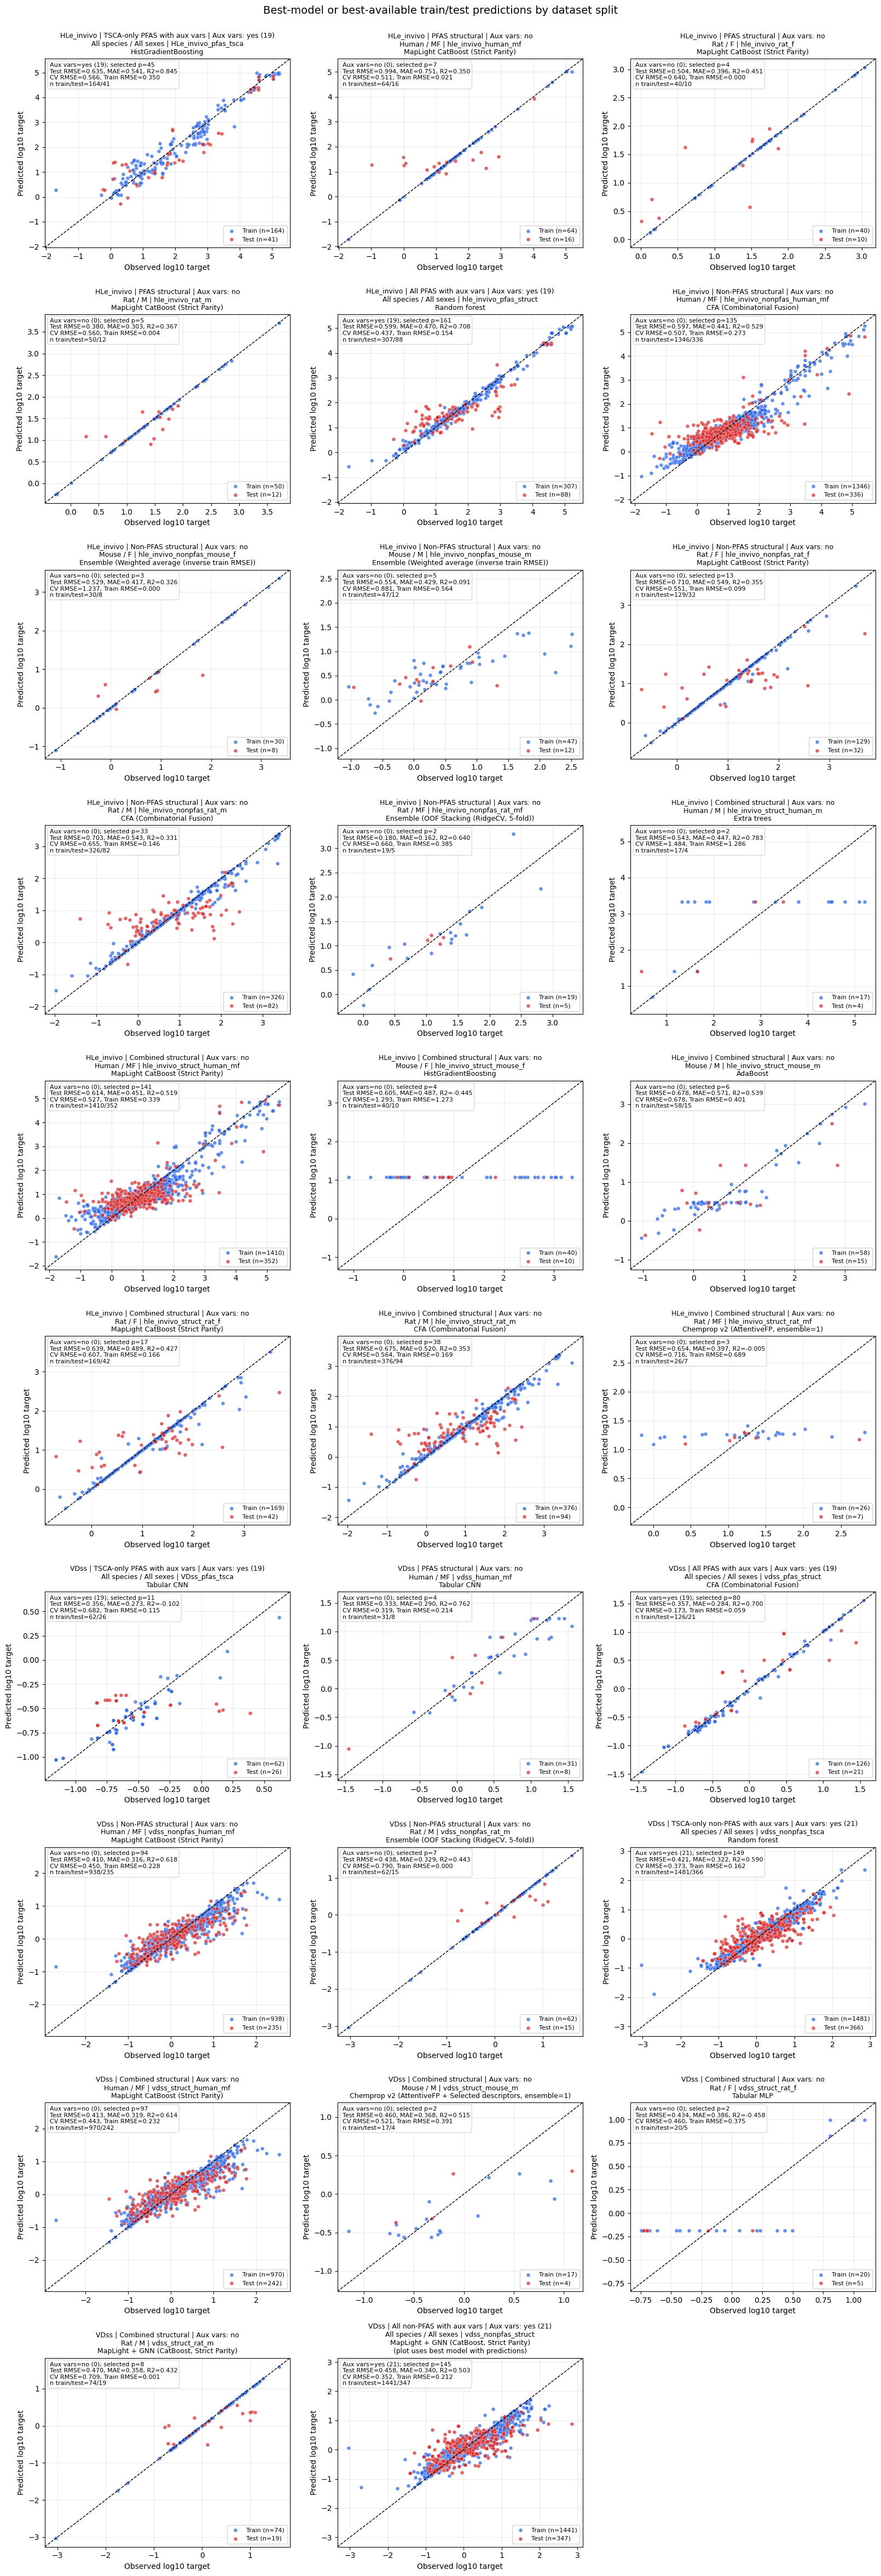

In [24]:
plot_df = pd.concat(plot_parts, ignore_index=True) if plot_parts else pd.DataFrame()
if plot_df.empty:
    raise ValueError('No train/test prediction rows found for best models or fallback plotted models.')
plot_df['observed'] = pd.to_numeric(plot_df['observed'], errors='coerce')
plot_df['predicted'] = pd.to_numeric(plot_df['predicted'], errors='coerce')
plot_df = plot_df.dropna(subset=['observed', 'predicted', 'dataset_label', 'target_family'])
if plot_df.empty:
    raise ValueError('Best-model prediction rows were found, but none had numeric observed/predicted values.')

plot_panels = best_model_performance[best_model_performance['has_scatter_predictions'].astype(bool)].copy()
plot_panels = plot_panels.sort_values(['target_family', 'structural_pool_sort', 'species', 'sex', 'dataset_label']).reset_index(drop=True)
if plot_panels.empty:
    raise ValueError('No best-model or fallback model prediction rows are available for scatterplots.')

colors = {'Train': '#2563eb', 'Test': '#dc2626'}

def _fmt(value, digits=3):
    try:
        value = float(value)
    except Exception:
        return 'NA'
    if not np.isfinite(value):
        return 'NA'
    return f'{value:.{digits}f}'

ncols = min(3, max(1, len(plot_panels)))
nrows = int(math.ceil(len(plot_panels) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.4 * ncols, 4.7 * nrows), squeeze=False, sharex=False, sharey=False)
axes_flat = axes.ravel()

for ax_idx, (_, perf) in enumerate(plot_panels.iterrows()):
    ax = axes_flat[ax_idx]
    sub = plot_df[
        plot_df['dataset'].eq(perf['dataset'])
        & plot_df['model'].eq(perf.get('scatter_model', perf.get('model', '')))
    ].copy()
    if sub.empty:
        ax.axis('off')
        continue
    for split_name in ['Train', 'Test']:
        split_sub = sub[sub['plot_split'].eq(split_name)]
        if split_sub.empty:
            continue
        ax.scatter(
            split_sub['observed'],
            split_sub['predicted'],
            s=24,
            alpha=0.72,
            color=colors[split_name],
            edgecolor='white',
            linewidth=0.35,
            label=f'{split_name} (n={len(split_sub)})',
        )
    lo = float(np.nanmin([sub['observed'].min(), sub['predicted'].min()]))
    hi = float(np.nanmax([sub['observed'].max(), sub['predicted'].max()]))
    pad = max((hi - lo) * 0.05, 0.05)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color='black', linewidth=1, linestyle='--')
    ax.set_xlim(lo - pad, hi + pad)
    ax.set_ylim(lo - pad, hi + pad)
    ax.set_xlabel('Observed log10 target')
    ax.set_ylabel('Predicted log10 target')
    ax.grid(True, alpha=0.25)
    ax.legend(loc='lower right', fontsize=8, frameon=True)
    model_note = '' if bool(perf.get('scatter_matches_best_model', True)) else '\n(plot uses best model with predictions)'
    aux_label = perf.get('auxiliary_complexity_label', 'Aux vars: unknown')
    title = (
        f"{perf.get('target_family', '')} | {perf.get('structural_pool', '')} | {aux_label}\n"
        f"{perf.get('species', '')} / {perf.get('sex', '')} | {perf.get('dataset_label', '')}\n"
        f"{perf.get('scatter_model', perf.get('model', ''))}{model_note}"
    )
    ax.set_title(title, fontsize=9)
    aux_count = perf.get('auxiliary_feature_count', 0)
    aux_count = 0 if pd.isna(aux_count) else int(aux_count)
    p_count = perf.get('adj_r2_feature_count', np.nan)
    p_text = 'NA' if pd.isna(p_count) else str(int(p_count))
    metrics_text = (
        f"Aux vars={'yes' if bool(perf.get('aux_vars_used', False)) else 'no'} ({aux_count}); selected p={p_text}\n"
        f"Test RMSE={_fmt(perf.get('test_rmse'))}, MAE={_fmt(perf.get('test_mae'))}, R2={_fmt(perf.get('test_r2'))}\n"
        f"CV RMSE={_fmt(perf.get('cv_rmse'))}, Train RMSE={_fmt(perf.get('train_rmse'))}\n"
        f"n train/test={int(perf.get('n_train', 0))}/{int(perf.get('n_test', 0))}"
    )
    ax.text(
        0.02,
        0.98,
        metrics_text,
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=8,
        bbox={'facecolor': 'white', 'edgecolor': '#d1d5db', 'alpha': 0.88, 'boxstyle': 'round,pad=0.3'},
    )

for ax in axes_flat[len(plot_panels):]:
    ax.axis('off')

fig.suptitle('Best-model or best-available train/test predictions by dataset split', y=1.0, fontsize=14)
fig.tight_layout()
plt.show()


## PFAS-Only Best Strategy by Endpoint, Species, and Sex

This final table answers the practical selection question directly: among all completed strategies, which model/data strategy gives the best PFAS-only test performance for each endpoint, species, and sex? Candidate rows are grouped only by endpoint/species/sex, not by TSCA-vs-structural source. The selected strategy reports whether the training data were PFAS-only or PFAS plus non-PFAS, whether auxiliary variables were used, the winning model, and the PFAS test-set size used for that decision.


In [25]:
MIN_PFAS_TEST_N_FOR_BEST = 2


def _strategy_training_scope(structural_pool):
    pool = str(structural_pool or '').lower()
    if 'combined' in pool or 'pfas + non' in pool:
        return 'PFAS + non-PFAS training'
    if 'non-pfas' in pool or 'nonpfas' in pool:
        return 'Non-PFAS-only training'
    return 'PFAS-only training'


def _strategy_source_detail(structural_pool):
    pool = str(structural_pool or '')
    pool_lower = pool.lower()
    if 'tsca' in pool_lower:
        return 'TSCA-only source'
    if 'combined' in pool_lower or 'pfas + non' in pool_lower:
        return 'combined structural source'
    if 'all pfas' in pool_lower:
        return 'all PFAS structural source'
    if 'all non-pfas' in pool_lower:
        return 'all non-PFAS structural source'
    if 'pfas structural' in pool_lower:
        return 'species/sex PFAS structural source'
    return pool or 'unknown source'


def _compute_pfas_strategy_candidates_by_species_sex(enriched_predictions):
    rows = enriched_predictions.copy()
    rows['observed'] = pd.to_numeric(rows['observed'], errors='coerce')
    rows['predicted'] = pd.to_numeric(rows['predicted'], errors='coerce')
    rows['is_pfas_chemical'] = rows['is_pfas_chemical'].fillna(False).astype(bool)
    rows = rows.dropna(subset=['observed', 'predicted', 'target_family', 'eval_species', 'eval_sex'])

    train_rows = rows[rows['plot_split'].eq('Train')].copy()
    test_rows = rows[rows['plot_split'].eq('Test') & rows['is_pfas_chemical']].copy()
    train_group_keys = ['dataset', 'model', 'target_family', 'eval_species', 'eval_sex']
    train_all_counts = train_rows.groupby(train_group_keys).size().rename('same_species_sex_train_rows')
    train_pfas_counts = train_rows[train_rows['is_pfas_chemical']].groupby(train_group_keys).size().rename('same_species_sex_pfas_train_rows')

    records = []
    candidate_group_keys = ['dataset', 'model', 'target_family', 'eval_species', 'eval_sex']
    for keys, sub in test_rows.groupby(candidate_group_keys, dropna=False):
        dataset, model, target_family, species, sex = keys
        first = sub.iloc[0]
        count_key = (dataset, model, target_family, species, sex)
        source_pool = first.get('structural_pool', '')
        training_scope = _strategy_training_scope(source_pool)
        records.append({
            'target_family': target_family,
            'species': species,
            'sex': sex,
            'source_dataset_label': first.get('dataset_label', dataset),
            'source_dataset_id': dataset,
            'source_pool': source_pool,
            'training_scope': training_scope,
            'source_detail': _strategy_source_detail(source_pool),
            'includes_nonpfas_training_data': training_scope == 'PFAS + non-PFAS training',
            'aux_vars_included': bool(first.get('aux_vars_used', False)),
            'auxiliary_feature_count': int(first.get('auxiliary_feature_count', 0) or 0),
            'model': model,
            'workflow': first.get('workflow', ''),
            'model_train_rows': int(first.get('n_train', 0) or 0),
            'model_test_rows': int(first.get('n_test', 0) or 0),
            'same_species_sex_train_rows': int(train_all_counts.get(count_key, 0)),
            'same_species_sex_pfas_train_rows': int(train_pfas_counts.get(count_key, 0)),
            'pfas_test_rows': int(len(sub)),
            'test_rmse': _rmse(sub['observed'], sub['predicted']),
            'test_mae': _mae(sub['observed'], sub['predicted']),
            'test_r2': _r2_score(sub['observed'], sub['predicted']),
        })
    candidates = pd.DataFrame(records)
    if candidates.empty:
        return candidates
    candidates['eligible_for_best_strategy'] = candidates['pfas_test_rows'] >= MIN_PFAS_TEST_N_FOR_BEST
    candidates['candidate_count_for_endpoint_species_sex'] = candidates.groupby(['target_family', 'species', 'sex'])['source_dataset_id'].transform('count')
    sort_species = {name: i for i, name in enumerate(SPECIES_ORDER)}
    sort_sex = {'F': 0, 'M': 1, 'MF': 2, 'All sexes': 3, 'Unknown': 50}
    candidates['species_sort'] = candidates['species'].map(sort_species).fillna(50)
    candidates['sex_sort'] = candidates['sex'].map(sort_sex).fillna(50)
    candidates = candidates.sort_values([
        'target_family', 'species_sort', 'sex_sort', 'eligible_for_best_strategy',
        'test_rmse', 'test_mae', 'pfas_test_rows', 'source_dataset_label'
    ], ascending=[True, True, True, False, True, True, False, True]).reset_index(drop=True)
    return candidates


pfas_strategy_candidates_by_species_sex = _compute_pfas_strategy_candidates_by_species_sex(enriched_plot_df)
if pfas_strategy_candidates_by_species_sex.empty:
    raise ValueError('No PFAS-only endpoint/species/sex strategy candidates could be computed from best-model predictions.')

best_rows = []
for keys, sub in pfas_strategy_candidates_by_species_sex.groupby(['target_family', 'species', 'sex'], dropna=False):
    eligible = sub[sub['eligible_for_best_strategy']].copy()
    ranking_pool = eligible if not eligible.empty else sub.copy()
    best = ranking_pool.sort_values(['test_rmse', 'test_mae', 'pfas_test_rows'], ascending=[True, True, False]).iloc[0]
    note = (
        f"ranked among candidates with >= {MIN_PFAS_TEST_N_FOR_BEST} PFAS test rows"
        if not eligible.empty
        else f"only candidates with < {MIN_PFAS_TEST_N_FOR_BEST} PFAS test rows were available; RMSE is unstable"
    )
    record = best.to_dict()
    record['selection_note'] = note
    best_rows.append(record)

pfas_best_strategy_by_endpoint_species_sex = pd.DataFrame(best_rows)
pfas_best_strategy_by_endpoint_species_sex = pfas_best_strategy_by_endpoint_species_sex.sort_values([
    'target_family', 'species_sort', 'sex_sort', 'test_rmse'
]).reset_index(drop=True)

simple_strategy_cols = [
    'target_family', 'species', 'sex', 'training_scope', 'aux_vars_included', 'auxiliary_feature_count',
    'model', 'workflow', 'source_dataset_label', 'model_train_rows', 'same_species_sex_train_rows',
    'same_species_sex_pfas_train_rows', 'pfas_test_rows', 'test_rmse', 'test_mae', 'test_r2',
    'candidate_count_for_endpoint_species_sex', 'selection_note'
]
display(pfas_best_strategy_by_endpoint_species_sex[[c for c in simple_strategy_cols if c in pfas_best_strategy_by_endpoint_species_sex.columns]])


,target_family,species,sex,training_scope,aux_vars_included,auxiliary_feature_count,model,workflow,source_dataset_label,model_train_rows,same_species_sex_train_rows,same_species_sex_pfas_train_rows,pfas_test_rows,test_rmse,test_mae,test_r2,candidate_count_for_endpoint_species_sex,selection_note
0,HLe_invivo,Human,F,PFAS-only training,True,19,Random forest,conventional,hle_invivo_pfas_struct,307,13,13,3,0.036302,0.029185,0.998997,2,ranked among candidates with >= 2 PFAS test rows
1,HLe_invivo,Human,M,PFAS-only training,True,19,Random forest,conventional,hle_invivo_pfas_struct,307,10,10,3,0.379016,0.256348,0.868642,2,ranked among candidates with >= 2 PFAS test rows
2,HLe_invivo,Human,MF,PFAS-only training,True,19,HistGradientBoosting,conventional,HLe_invivo_pfas_tsca,164,14,14,4,0.229709,0.223414,-0.062949,4,ranked among candidates with >= 2 PFAS test rows
3,HLe_invivo,Monkey,F,PFAS-only training,True,19,Random forest,conventional,hle_invivo_pfas_struct,307,9,9,2,0.979536,0.915349,-19.978617,2,ranked among candidates with >= 2 PFAS test rows
4,HLe_invivo,Monkey,M,PFAS-only training,True,19,Random forest,conventional,hle_invivo_pfas_struct,307,10,10,2,0.887343,0.861888,-719.885269,2,ranked among candidates with >= 2 PFAS test rows
5,HLe_invivo,Monkey,MF,PFAS-only training,True,19,Random forest,conventional,hle_invivo_pfas_struct,307,0,0,1,0.085883,0.085883,NaN,1,only candidates with < 2 PFAS test rows were a...
6,HLe_invivo,Mouse,F,PFAS-only training,True,19,Random forest,conventional,hle_invivo_pfas_struct,307,14,14,4,0.326570,0.301923,0.895497,2,ranked among candidates with >= 2 PFAS test rows
7,HLe_invivo,Mouse,M,PFAS-only training,True,19,Random forest,conventional,hle_invivo_pfas_struct,307,14,14,5,0.454633,0.389110,0.802170,2,ranked among candidates with >= 2 PFAS test rows
8,HLe_invivo,Rat,F,PFAS-only training,False,0,MapLight CatBoost (Strict Parity),conventional,hle_invivo_rat_f,40,40,40,10,0.503661,0.396398,0.450625,4,ranked among candidates with >= 2 PFAS test rows
9,HLe_invivo,Rat,M,PFAS-only training,False,0,MapLight CatBoost (Strict Parity),conventional,hle_invivo_rat_m,50,50,50,12,0.380034,0.302978,0.367395,4,ranked among candidates with >= 2 PFAS test rows


## PFAS-Only Best-Strategy Scatterplots

These scatterplots visualize the selected strategy from the table above for each endpoint/species/sex combination. Blue points are same-species/sex training rows used by the selected model; open blue points indicate non-PFAS training chemicals when the selected strategy used PFAS plus non-PFAS training data. Red points are PFAS test rows used for the PFAS-only strategy ranking. Each panel reports the selected dataset, model, auxiliary-variable status, training/test sizes, and PFAS-only test metrics.


,strategy_target_family,strategy_species,strategy_sex,scatter_role,points
0,HLe_invivo,Human,F,PFAS test,3
1,HLe_invivo,Human,F,Train PFAS,13
2,HLe_invivo,Human,M,PFAS test,3
3,HLe_invivo,Human,M,Train PFAS,10
4,HLe_invivo,Human,MF,PFAS test,4
5,HLe_invivo,Human,MF,Train PFAS,14
6,HLe_invivo,Monkey,F,PFAS test,2
7,HLe_invivo,Monkey,F,Train PFAS,9
8,HLe_invivo,Monkey,M,PFAS test,2
9,HLe_invivo,Monkey,M,Train PFAS,10


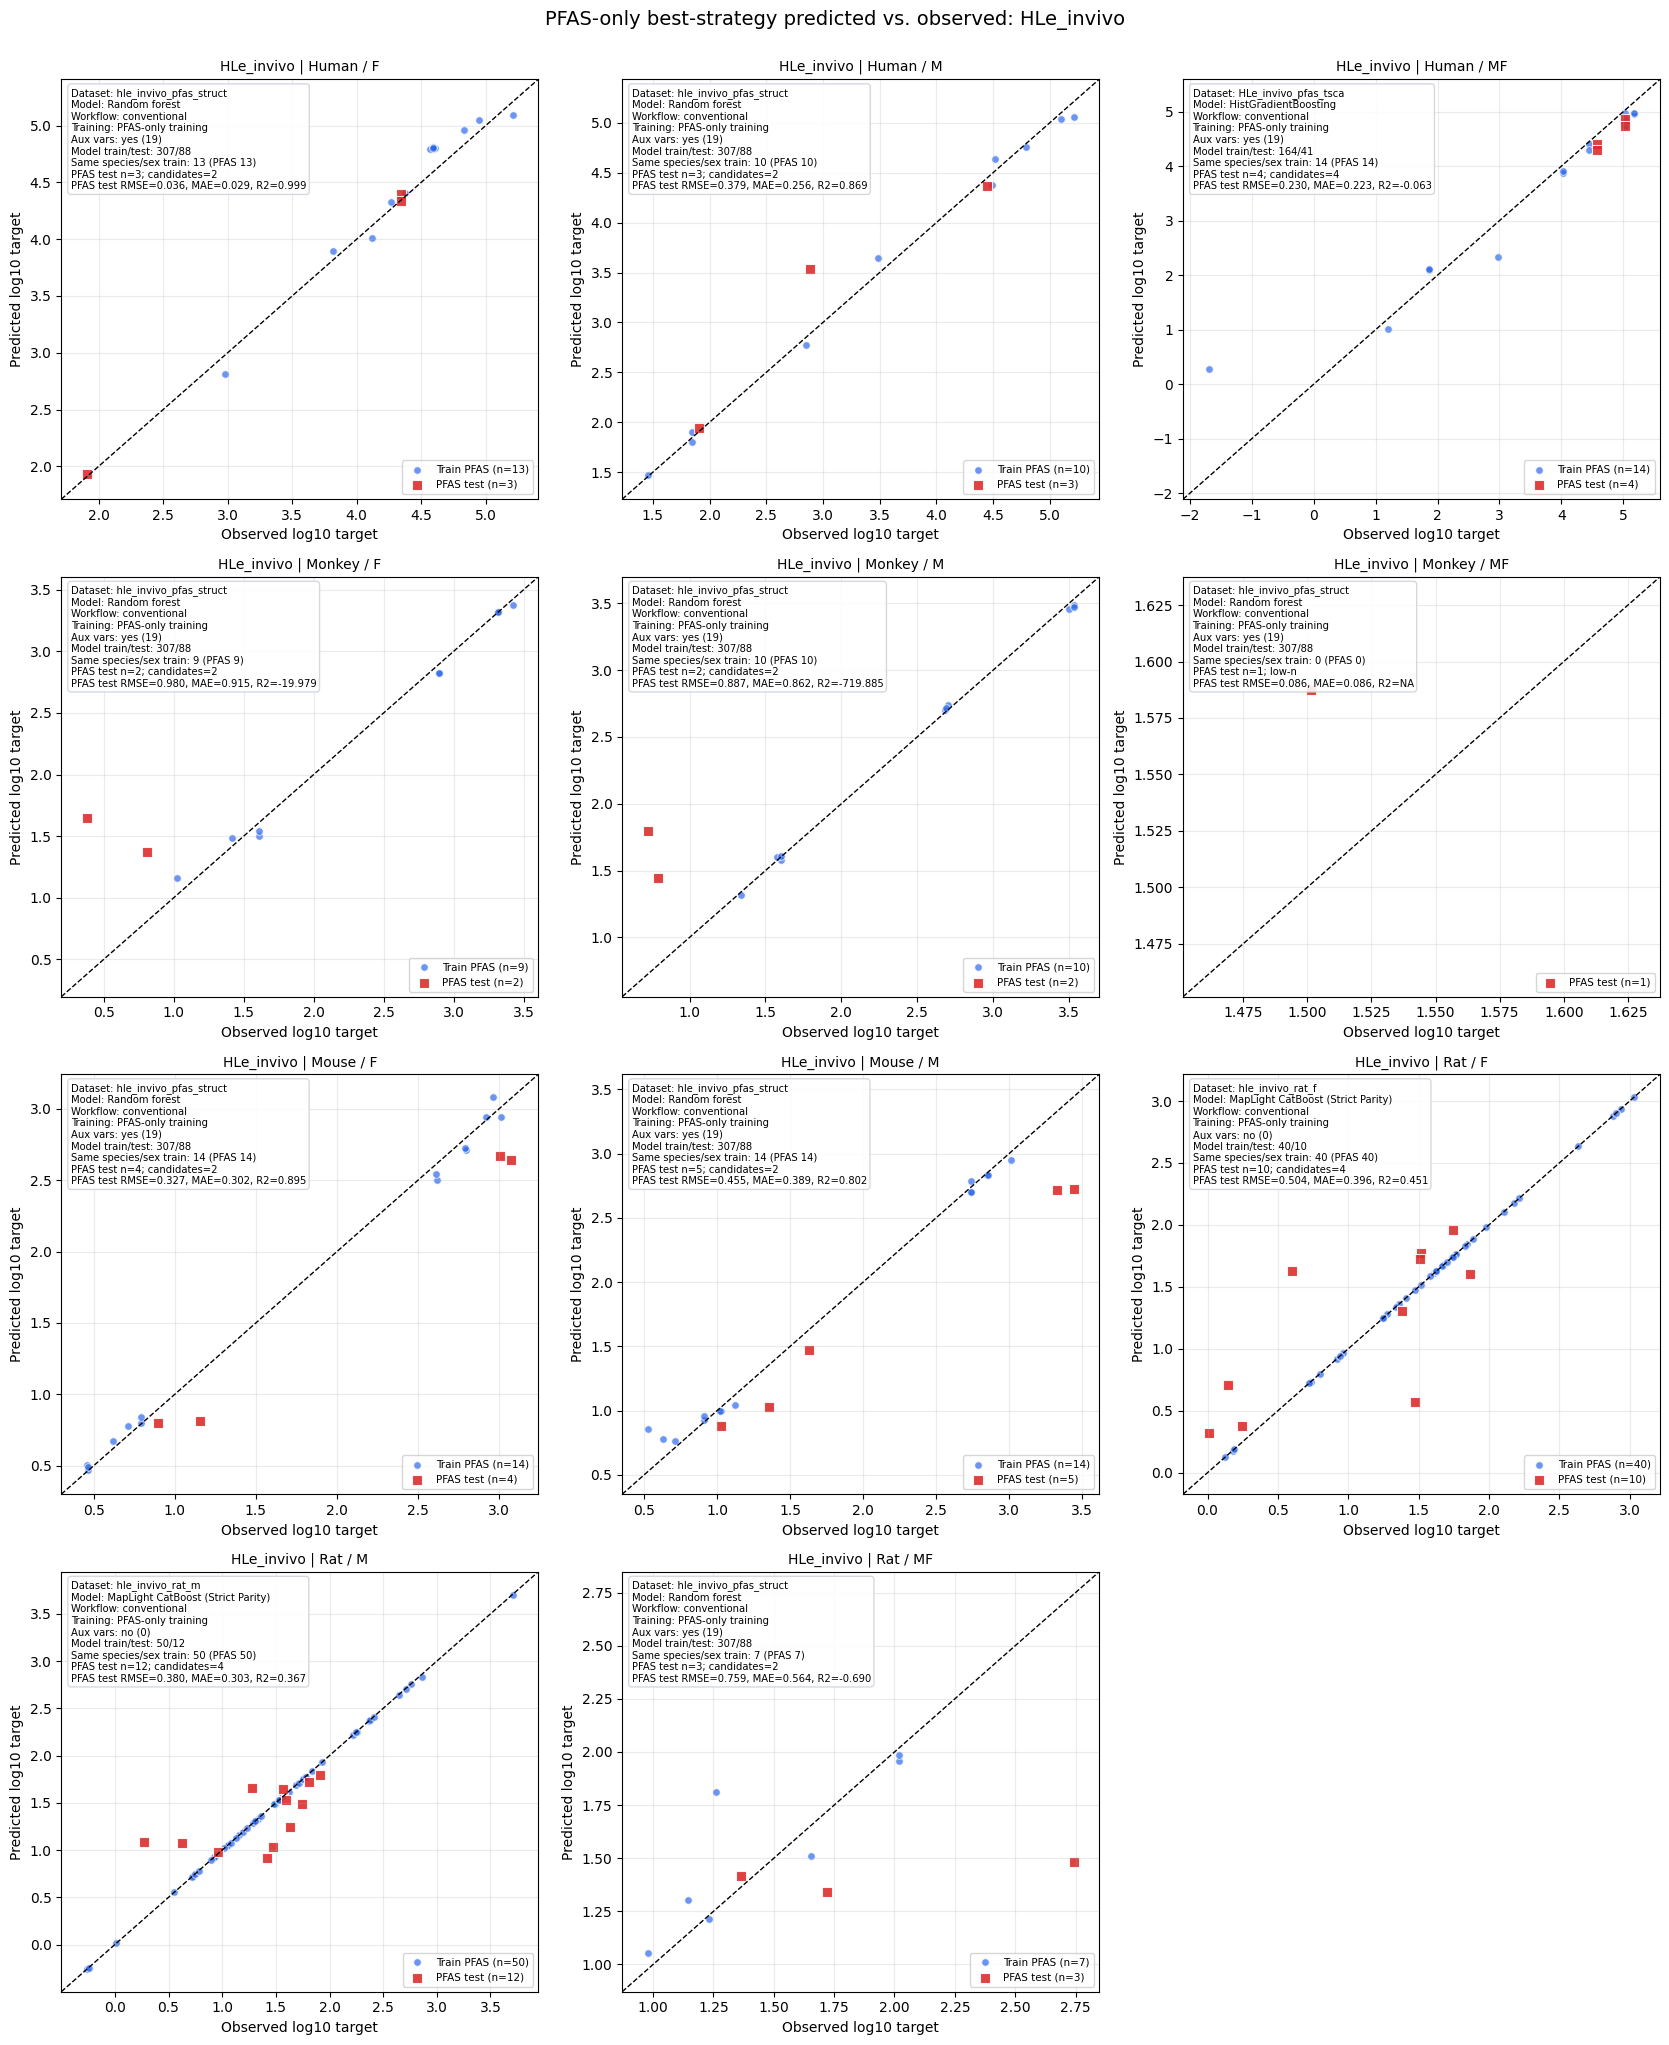

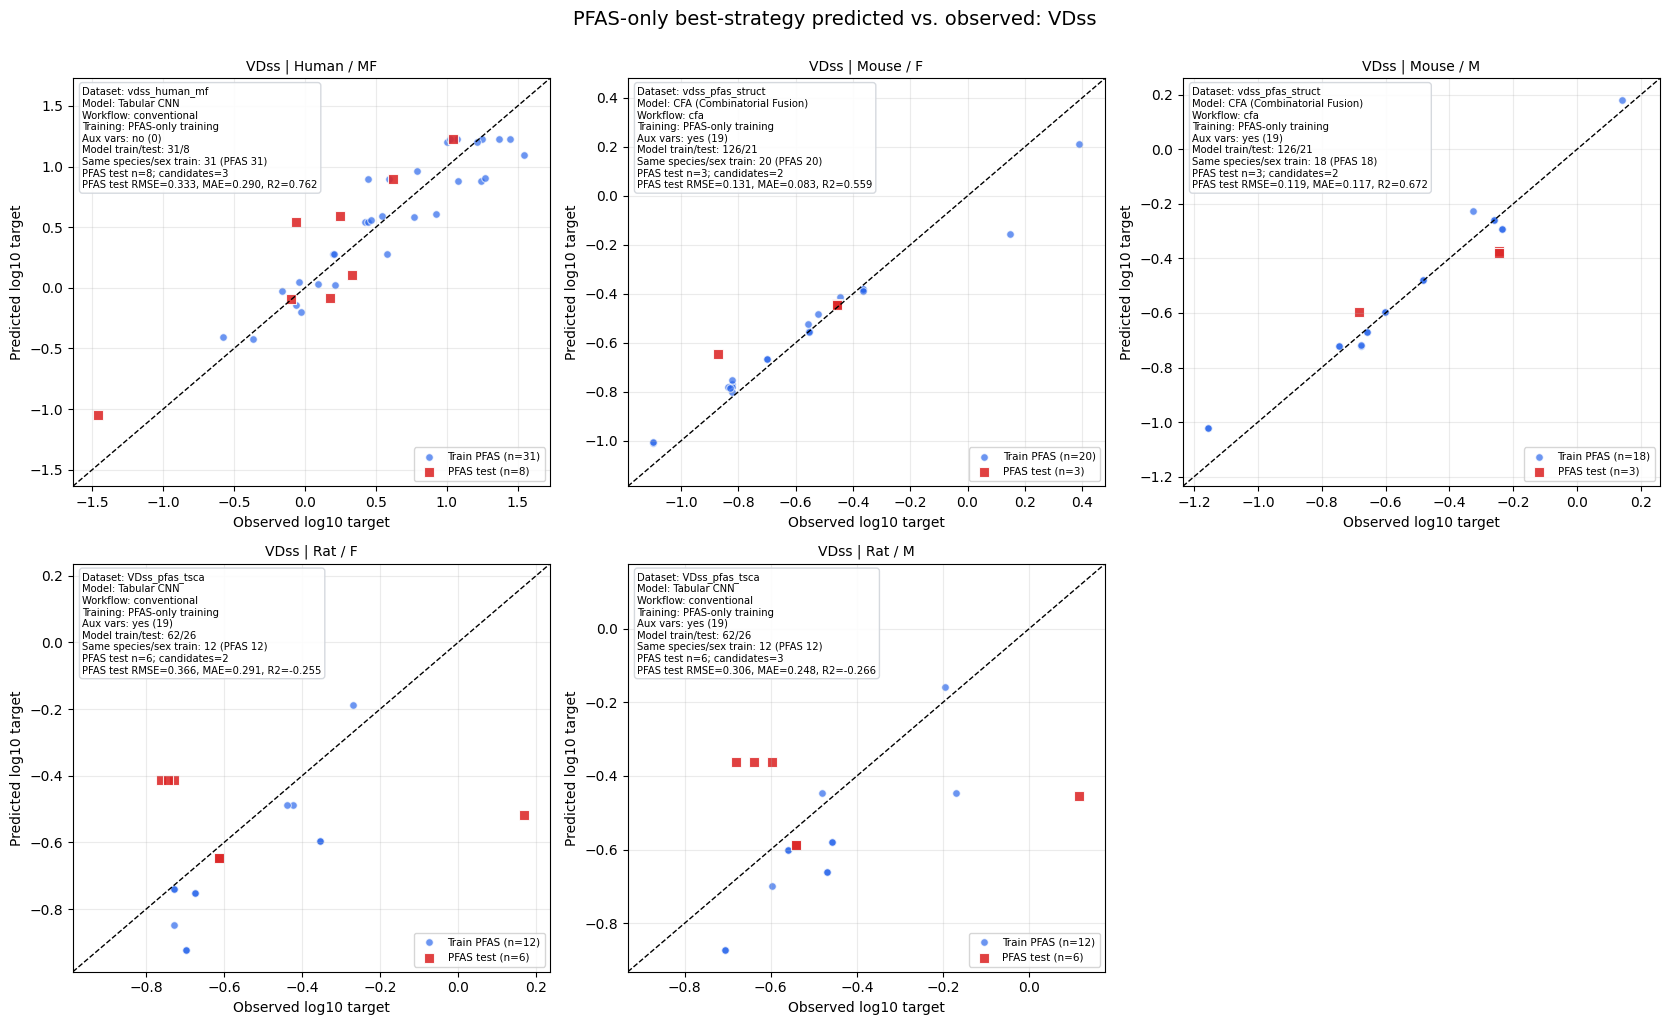

In [26]:
def _best_strategy_scatter_points(enriched_predictions, best_strategy_table):
    rows = []
    for _, strategy_row in best_strategy_table.iterrows():
        dataset = strategy_row.get('source_dataset_id', strategy_row.get('source_dataset_label', ''))
        model = strategy_row.get('model', '')
        endpoint = strategy_row.get('target_family', '')
        species = strategy_row.get('species', '')
        sex = strategy_row.get('sex', '')
        sub = enriched_predictions[
            enriched_predictions['dataset'].astype(str).eq(str(dataset))
            & enriched_predictions['model'].astype(str).eq(str(model))
            & enriched_predictions['target_family'].astype(str).eq(str(endpoint))
            & enriched_predictions['eval_species'].astype(str).eq(str(species))
            & enriched_predictions['eval_sex'].astype(str).eq(str(sex))
        ].copy()
        if sub.empty:
            continue
        sub['observed'] = pd.to_numeric(sub['observed'], errors='coerce')
        sub['predicted'] = pd.to_numeric(sub['predicted'], errors='coerce')
        sub['is_pfas_chemical'] = sub['is_pfas_chemical'].fillna(False).astype(bool)
        sub = sub.dropna(subset=['observed', 'predicted'])
        if sub.empty:
            continue
        train_sub = sub[sub['plot_split'].eq('Train')].copy()
        test_sub = sub[sub['plot_split'].eq('Test') & sub['is_pfas_chemical']].copy()
        for split_label, split_frame in [('Train', train_sub), ('PFAS test', test_sub)]:
            if split_frame.empty:
                continue
            frame = split_frame.copy()
            frame['strategy_target_family'] = endpoint
            frame['strategy_species'] = species
            frame['strategy_sex'] = sex
            frame['strategy_training_scope'] = strategy_row.get('training_scope', '')
            frame['strategy_source_dataset_label'] = strategy_row.get('source_dataset_label', dataset)
            frame['strategy_model'] = model
            frame['strategy_workflow'] = strategy_row.get('workflow', '')
            frame['strategy_aux_vars_included'] = bool(strategy_row.get('aux_vars_included', False))
            frame['strategy_auxiliary_feature_count'] = int(strategy_row.get('auxiliary_feature_count', 0) or 0)
            frame['strategy_model_train_rows'] = int(strategy_row.get('model_train_rows', 0) or 0)
            frame['strategy_model_test_rows'] = int(strategy_row.get('model_test_rows', 0) or 0)
            frame['strategy_same_species_sex_train_rows'] = int(strategy_row.get('same_species_sex_train_rows', 0) or 0)
            frame['strategy_same_species_sex_pfas_train_rows'] = int(strategy_row.get('same_species_sex_pfas_train_rows', 0) or 0)
            frame['strategy_pfas_test_rows'] = int(strategy_row.get('pfas_test_rows', 0) or 0)
            frame['strategy_test_rmse'] = strategy_row.get('test_rmse', np.nan)
            frame['strategy_test_mae'] = strategy_row.get('test_mae', np.nan)
            frame['strategy_test_r2'] = strategy_row.get('test_r2', np.nan)
            frame['strategy_selection_note'] = strategy_row.get('selection_note', '')
            frame['scatter_split'] = split_label
            if split_label == 'Train':
                frame['scatter_role'] = np.where(frame['is_pfas_chemical'], 'Train PFAS', 'Train non-PFAS')
            else:
                frame['scatter_role'] = 'PFAS test'
            rows.append(frame)
    if not rows:
        return pd.DataFrame()
    out = pd.concat(rows, ignore_index=True, sort=False)
    keep_cols = [
        'strategy_target_family', 'strategy_species', 'strategy_sex', 'strategy_training_scope',
        'strategy_source_dataset_label', 'strategy_model', 'strategy_workflow', 'strategy_aux_vars_included',
        'strategy_auxiliary_feature_count', 'strategy_model_train_rows', 'strategy_model_test_rows',
        'strategy_same_species_sex_train_rows', 'strategy_same_species_sex_pfas_train_rows',
        'strategy_pfas_test_rows', 'strategy_test_rmse', 'strategy_test_mae', 'strategy_test_r2',
        'strategy_selection_note', 'scatter_split', 'scatter_role', 'is_pfas_chemical',
        'dataset', 'model', 'workflow', 'plot_split', 'smiles', 'observed', 'predicted',
        'eval_species', 'eval_sex'
    ]
    return out[[c for c in keep_cols if c in out.columns]]


def _axis_limits_for_points(frame):
    lo = float(np.nanmin([frame['observed'].min(), frame['predicted'].min()]))
    hi = float(np.nanmax([frame['observed'].max(), frame['predicted'].max()]))
    if not np.isfinite(lo) or not np.isfinite(hi):
        return -1.0, 1.0
    if hi <= lo:
        pad = max(abs(lo) * 0.08, 0.1)
    else:
        pad = max((hi - lo) * 0.06, 0.05)
    return lo - pad, hi + pad


def _plot_best_strategy_scatter_matrix(scatter_points):
    if scatter_points.empty:
        print('No best-strategy scatter points were available to plot.')
        return
    role_styles = {
        'Train PFAS': {'color': '#2563eb', 'marker': 'o', 'face': '#2563eb', 'alpha': 0.68, 'label': 'Train PFAS'},
        'Train non-PFAS': {'color': '#2563eb', 'marker': 'o', 'face': 'none', 'alpha': 0.82, 'label': 'Train non-PFAS'},
        'PFAS test': {'color': '#dc2626', 'marker': 's', 'face': '#dc2626', 'alpha': 0.88, 'label': 'PFAS test'},
    }
    for endpoint, endpoint_rows in scatter_points.groupby('strategy_target_family', sort=False):
        panels = (
            endpoint_rows[['strategy_species', 'strategy_sex']]
            .drop_duplicates()
            .assign(
                species_sort=lambda df: df['strategy_species'].map({name: i for i, name in enumerate(SPECIES_ORDER)}).fillna(50),
                sex_sort=lambda df: df['strategy_sex'].map({'F': 0, 'M': 1, 'MF': 2, 'All sexes': 3}).fillna(50),
            )
            .sort_values(['species_sort', 'sex_sort', 'strategy_species', 'strategy_sex'])
            .reset_index(drop=True)
        )
        ncols = min(3, max(1, len(panels)))
        nrows = int(math.ceil(len(panels) / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(5.6 * ncols, 5.1 * nrows), squeeze=False)
        axes_flat = axes.ravel()
        for ax_idx, (_, panel) in enumerate(panels.iterrows()):
            ax = axes_flat[ax_idx]
            sub = endpoint_rows[
                endpoint_rows['strategy_species'].eq(panel['strategy_species'])
                & endpoint_rows['strategy_sex'].eq(panel['strategy_sex'])
            ].copy()
            if sub.empty:
                ax.axis('off')
                continue
            for role, style in role_styles.items():
                role_sub = sub[sub['scatter_role'].eq(role)]
                if role_sub.empty:
                    continue
                facecolor = style['face']
                ax.scatter(
                    role_sub['observed'],
                    role_sub['predicted'],
                    s=30 if role != 'PFAS test' else 42,
                    marker=style['marker'],
                    facecolors=facecolor,
                    edgecolors=style['color'] if facecolor == 'none' else 'white',
                    color=style['color'] if facecolor != 'none' else None,
                    linewidth=0.8,
                    alpha=style['alpha'],
                    label=f"{style['label']} (n={len(role_sub)})",
                )
            lo, hi = _axis_limits_for_points(sub)
            ax.plot([lo, hi], [lo, hi], color='black', linewidth=1.0, linestyle='--')
            ax.set_xlim(lo, hi)
            ax.set_ylim(lo, hi)
            ax.set_xlabel('Observed log10 target')
            ax.set_ylabel('Predicted log10 target')
            ax.grid(True, alpha=0.25)
            ax.legend(loc='lower right', fontsize=7.5, frameon=True)
            first = sub.iloc[0]
            ax.set_title(f"{endpoint} | {panel['strategy_species']} / {panel['strategy_sex']}", fontsize=10)
            aux_text = 'yes' if bool(first.get('strategy_aux_vars_included', False)) else 'no'
            r2_value = first.get('strategy_test_r2', np.nan)
            r2_text = 'NA' if pd.isna(r2_value) else f"{float(r2_value):.3f}"
            note = str(first.get('strategy_selection_note', ''))
            note_text = 'low-n' if 'unstable' in note.lower() else f"candidates={int(pfas_strategy_candidates_by_species_sex[(pfas_strategy_candidates_by_species_sex['target_family'].eq(endpoint)) & (pfas_strategy_candidates_by_species_sex['species'].eq(panel['strategy_species'])) & (pfas_strategy_candidates_by_species_sex['sex'].eq(panel['strategy_sex']))].shape[0])}"
            info_text = (
                f"Dataset: {first.get('strategy_source_dataset_label', '')}\n"
                f"Model: {first.get('strategy_model', '')}\n"
                f"Workflow: {first.get('strategy_workflow', '')}\n"
                f"Training: {first.get('strategy_training_scope', '')}\n"
                f"Aux vars: {aux_text} ({int(first.get('strategy_auxiliary_feature_count', 0) or 0)})\n"
                f"Model train/test: {int(first.get('strategy_model_train_rows', 0) or 0)}/{int(first.get('strategy_model_test_rows', 0) or 0)}\n"
                f"Same species/sex train: {int(first.get('strategy_same_species_sex_train_rows', 0) or 0)} "
                f"(PFAS {int(first.get('strategy_same_species_sex_pfas_train_rows', 0) or 0)})\n"
                f"PFAS test n={int(first.get('strategy_pfas_test_rows', 0) or 0)}; {note_text}\n"
                f"PFAS test RMSE={float(first.get('strategy_test_rmse', np.nan)):.3f}, "
                f"MAE={float(first.get('strategy_test_mae', np.nan)):.3f}, R2={r2_text}"
            )
            ax.text(
                0.02,
                0.98,
                info_text,
                transform=ax.transAxes,
                ha='left',
                va='top',
                fontsize=7.2,
                bbox={'facecolor': 'white', 'edgecolor': '#d1d5db', 'alpha': 0.9, 'boxstyle': 'round,pad=0.3'},
            )
        for ax in axes_flat[len(panels):]:
            ax.axis('off')
        fig.suptitle(f'PFAS-only best-strategy predicted vs. observed: {endpoint}', y=1.0, fontsize=14)
        fig.tight_layout()
        plt.show()


pfas_best_strategy_scatter_points = _best_strategy_scatter_points(
    enriched_plot_df,
    pfas_best_strategy_by_endpoint_species_sex,
)
if pfas_best_strategy_scatter_points.empty:
    raise ValueError('No train/test scatter points could be assembled for the PFAS-only best strategies.')
display(
    pfas_best_strategy_scatter_points
    .groupby(['strategy_target_family', 'strategy_species', 'strategy_sex', 'scatter_role'], dropna=False)
    .size()
    .rename('points')
    .reset_index()
)
_plot_best_strategy_scatter_matrix(pfas_best_strategy_scatter_points)


## Human PFAS Prediction Recommendations

This section turns the preceding PFAS-only strategy ranking into a direct recommendation for human PFAS prediction by sex. It is dynamic: each run re-ranks the available HLe_invivo and VDss candidate strategies for Human/F and Human/M using PFAS-only test performance, while also reporting evidence strength from sample size, auxiliary-variable use, model class, and whether the evidence is sex-specific or a pooled-sex fallback.


### Current Human PFAS Recommendation From This Run

The next cell derives the current-run recommendation from the completed benchmark artifacts, then shows the chosen dataset/model strategy by endpoint and sex plus an endpoint-level assessment of performance, robustness, and generalizability. Rerunning the notebook updates these recommendations and the exported CSV files from the data available in that run.


In [27]:
try:
    from IPython.display import Markdown
except Exception:
    Markdown = lambda value: value

HUMAN_RECOMMENDATION_ENDPOINTS = ['HLe_invivo', 'VDss']
HUMAN_RECOMMENDATION_SEXES = ['F', 'M']
FALLBACK_HUMAN_SEXES = ['MF', 'All sexes', 'pooled', 'Unknown']


def _metric_text(value, digits=3):
    try:
        value = float(value)
    except Exception:
        return 'NA'
    if not np.isfinite(value):
        return 'NA'
    return f'{value:.{digits}f}'


def _rank_strategy_candidates(candidates):
    if candidates.empty:
        return candidates.copy()
    ranked = candidates.copy()
    for col in ['pfas_test_rows', 'same_species_sex_pfas_train_rows', 'test_rmse', 'test_mae', 'test_r2']:
        ranked[col] = pd.to_numeric(ranked[col], errors='coerce')
    ranked['eligible_for_best_strategy'] = ranked.get('eligible_for_best_strategy', False).fillna(False).astype(bool)
    ranked['uses_nonpfas_training'] = ranked.get('includes_nonpfas_training_data', False).fillna(False).astype(bool)
    return ranked.sort_values(
        ['eligible_for_best_strategy', 'test_rmse', 'test_mae', 'pfas_test_rows', 'same_species_sex_pfas_train_rows'],
        ascending=[False, True, True, False, False],
    ).reset_index(drop=True)


def _finite_or_nan(value):
    try:
        value = float(value)
    except Exception:
        return np.nan
    return value if np.isfinite(value) else np.nan


def _human_evidence_strength(row, exact_sex_match):
    test_n = int(row.get('pfas_test_rows', 0) or 0)
    train_n = int(row.get('same_species_sex_pfas_train_rows', 0) or 0)
    r2 = _finite_or_nan(row.get('test_r2', np.nan))
    if not exact_sex_match:
        return 'Limited - pooled-sex fallback'
    if test_n >= 8 and train_n >= 20 and np.isfinite(r2) and r2 >= 0.5:
        return 'Strong'
    if test_n >= 5 and train_n >= 10 and (not np.isfinite(r2) or r2 >= 0.0):
        return 'Moderate'
    return 'Limited - small PFAS sex-specific test set'


def _performance_lens(row, candidate_count):
    return (
        f"Lowest PFAS-only test RMSE among {int(candidate_count)} candidate strategy(s): "
        f"RMSE={_metric_text(row.get('test_rmse'))}, "
        f"MAE={_metric_text(row.get('test_mae'))}, "
        f"R2={_metric_text(row.get('test_r2'))}."
    )


def _robustness_lens(row, exact_sex_match):
    test_n = int(row.get('pfas_test_rows', 0) or 0)
    train_n = int(row.get('same_species_sex_pfas_train_rows', 0) or 0)
    model_train_n = int(row.get('model_train_rows', 0) or 0)
    requested_sex = row.get('requested_sex', '')
    evidence_sex = row.get('evidence_sex', '')
    if not exact_sex_match:
        return f"No Human/{requested_sex} candidate completed; evidence uses Human/{evidence_sex} with {test_n} PFAS test row(s)."
    if test_n < 5:
        return f"Sex-specific, but PFAS test n={test_n}; treat as provisional despite model train n={model_train_n}."
    return f"Sex-specific PFAS test n={test_n}; same-sex PFAS train n={train_n}; model train n={model_train_n}."


def _generalizability_lens(row):
    scope = str(row.get('training_scope', ''))
    aux = bool(row.get('aux_vars_included', False))
    if scope == 'PFAS + non-PFAS training':
        scope_text = 'uses broader structural analog training data; check PFAS-domain calibration before deployment'
    elif scope == 'PFAS-only training':
        scope_text = 'stays inside the PFAS chemical domain; less extrapolation to non-PFAS chemistry'
    else:
        scope_text = 'uses a narrow or non-PFAS training scope; interpret cautiously for PFAS deployment'
    aux_text = 'includes aux physiology/sex/species variables' if aux else 'SMILES-only/no aux variables'
    return f"{scope_text}; {aux_text}."


def _recommendation_action(row, evidence_strength):
    endpoint = row.get('target_family', '')
    sex = row.get('requested_sex', '')
    if evidence_strength.startswith('Strong') or evidence_strength.startswith('Moderate'):
        return f"Use this as the current run's recommended Human/{sex} {endpoint} PFAS prediction strategy."
    if 'pooled-sex fallback' in evidence_strength:
        return f"Use only as an interim Human/{sex} {endpoint} fallback; run/complete sex-specific Human/{sex} PFAS candidates before treating it as sex-specific."
    return f"Best observed Human/{sex} {endpoint} strategy in this run, but collect or complete more sex-specific PFAS test data before relying on it operationally."


def _build_human_pfas_recommendations(candidates):
    recommendation_rows = []
    candidate_rows = []
    for endpoint in HUMAN_RECOMMENDATION_ENDPOINTS:
        for requested_sex in HUMAN_RECOMMENDATION_SEXES:
            exact = candidates[
                candidates['target_family'].astype(str).eq(endpoint)
                & candidates['species'].astype(str).eq('Human')
                & candidates['sex'].astype(str).eq(requested_sex)
            ].copy()
            exact_sex_match = not exact.empty
            if exact_sex_match:
                pool = exact.copy()
                evidence_basis = 'Human sex-specific PFAS test rows'
            else:
                pool = candidates[
                    candidates['target_family'].astype(str).eq(endpoint)
                    & candidates['species'].astype(str).eq('Human')
                    & candidates['sex'].astype(str).isin(FALLBACK_HUMAN_SEXES)
                ].copy()
                evidence_basis = 'Human pooled-sex fallback; no completed Human sex-specific row found'
            if pool.empty:
                recommendation_rows.append({
                    'target_family': endpoint,
                    'requested_species': 'Human',
                    'requested_sex': requested_sex,
                    'recommendation': 'No completed PFAS-only human candidate available in this run.',
                    'evidence_strength': 'Missing',
                    'evidence_basis': 'No exact or pooled human candidate found',
                })
                continue
            pool['requested_species'] = 'Human'
            pool['requested_sex'] = requested_sex
            pool['exact_sex_match'] = exact_sex_match
            pool['evidence_basis'] = evidence_basis
            candidate_rows.append(pool)
            ranked = _rank_strategy_candidates(pool)
            best = ranked.iloc[0].copy()
            best['requested_species'] = 'Human'
            best['requested_sex'] = requested_sex
            best['evidence_sex'] = best.get('sex', '')
            best['exact_sex_match'] = exact_sex_match
            best['evidence_basis'] = evidence_basis
            candidate_count = int(len(pool))
            evidence_strength = _human_evidence_strength(best, exact_sex_match)
            recommendation_rows.append({
                'target_family': endpoint,
                'requested_species': 'Human',
                'requested_sex': requested_sex,
                'recommended_dataset': best.get('source_dataset_label', ''),
                'recommended_model': best.get('model', ''),
                'workflow': best.get('workflow', ''),
                'training_scope': best.get('training_scope', ''),
                'includes_nonpfas_training_data': bool(best.get('includes_nonpfas_training_data', False)),
                'aux_vars_included': bool(best.get('aux_vars_included', False)),
                'auxiliary_feature_count': int(best.get('auxiliary_feature_count', 0) or 0),
                'evidence_sex': best.get('evidence_sex', ''),
                'exact_sex_match': exact_sex_match,
                'evidence_basis': evidence_basis,
                'candidate_count': candidate_count,
                'model_train_rows': int(best.get('model_train_rows', 0) or 0),
                'same_species_sex_pfas_train_rows': int(best.get('same_species_sex_pfas_train_rows', 0) or 0),
                'pfas_test_rows': int(best.get('pfas_test_rows', 0) or 0),
                'test_rmse': best.get('test_rmse', np.nan),
                'test_mae': best.get('test_mae', np.nan),
                'test_r2': best.get('test_r2', np.nan),
                'evidence_strength': evidence_strength,
                'performance_lens': _performance_lens(best, candidate_count),
                'robustness_lens': _robustness_lens(best, exact_sex_match),
                'generalizability_lens': _generalizability_lens(best),
                'recommendation': _recommendation_action(best, evidence_strength),
            })
    recommendation_table = pd.DataFrame(recommendation_rows)
    candidate_table = pd.concat(candidate_rows, ignore_index=True, sort=False) if candidate_rows else pd.DataFrame()
    if not candidate_table.empty:
        candidate_table = _rank_strategy_candidates(candidate_table)
    return recommendation_table, candidate_table


human_pfas_recommendations, human_pfas_recommendation_candidates = _build_human_pfas_recommendations(
    pfas_strategy_candidates_by_species_sex
)

human_recommendation_cols = [
    'target_family', 'requested_species', 'requested_sex', 'recommended_dataset', 'recommended_model',
    'workflow', 'training_scope', 'includes_nonpfas_training_data', 'aux_vars_included',
    'auxiliary_feature_count', 'evidence_sex', 'exact_sex_match', 'candidate_count',
    'model_train_rows', 'same_species_sex_pfas_train_rows', 'pfas_test_rows',
    'test_rmse', 'test_mae', 'test_r2', 'evidence_strength', 'performance_lens',
    'robustness_lens', 'generalizability_lens', 'recommendation'
]
display(Markdown('#### Recommended Strategy By Endpoint And Sex'))
display(human_pfas_recommendations[[c for c in human_recommendation_cols if c in human_pfas_recommendations.columns]])

def _human_recommendation_endpoint_assessment(recommendations):
    rows = []
    for endpoint, sub in recommendations.groupby('target_family', sort=False):
        sub = sub.copy()
        available = sub[sub['recommended_dataset'].notna()].copy() if 'recommended_dataset' in sub else pd.DataFrame()
        if available.empty:
            rows.append({
                'target_family': endpoint,
                'overall_recommendation': 'No completed human PFAS recommendation available in this run.',
                'performance_assessment': 'No candidate rows were available.',
                'robustness_assessment': 'Missing evidence.',
                'generalizability_assessment': 'Cannot assess.',
                'recommended_next_step': 'Complete at least one human PFAS strategy for each requested sex.',
            })
            continue
        sex_summaries = []
        for _, row in available.sort_values('requested_sex').iterrows():
            sex_summaries.append(
                f"Human/{row.get('requested_sex', '')}: {row.get('recommended_model', '')} on {row.get('recommended_dataset', '')} "
                f"(RMSE={_metric_text(row.get('test_rmse'))}, R2={_metric_text(row.get('test_r2'))}, "
                f"n_test={int(row.get('pfas_test_rows', 0) or 0)})"
            )
        training_scopes = sorted(set(available['training_scope'].dropna().astype(str)))
        aux_values = sorted(set(available['aux_vars_included'].dropna().astype(bool))) if 'aux_vars_included' in available else []
        scope_text = '; '.join(training_scopes) if training_scopes else 'unknown training scope'
        if aux_values == [True]:
            aux_text = 'auxiliary variables are used for all current winners'
        elif aux_values == [False]:
            aux_text = 'current winners are SMILES-only/no auxiliary variables'
        else:
            aux_text = 'auxiliary-variable use differs by sex or fallback row'
        exact_count = int(available.get('exact_sex_match', pd.Series(False, index=available.index)).fillna(False).astype(bool).sum())
        requested_count = int(len(available))
        limited_rows = available[available['evidence_strength'].astype(str).str.startswith('Limited', na=False)]
        if exact_count < requested_count:
            robustness = (
                f"Only {exact_count}/{requested_count} requested sex-specific rows are available; "
                "pooled-sex fallback rows should not be treated as sex-specific evidence."
            )
        elif not limited_rows.empty:
            min_test = int(pd.to_numeric(available['pfas_test_rows'], errors='coerce').min())
            robustness = (
                f"All requested sexes have sex-specific rows, but at least one recommendation is limited; "
                f"minimum PFAS test n={min_test}."
            )
        else:
            robustness = 'All requested sexes have direct human sex-specific evidence with at least moderate support.'
        if set(training_scopes) == {'PFAS-only training'}:
            generalizability = (
                'The current run favors staying inside the PFAS domain rather than adding non-PFAS chemicals; '
                'this reduces cross-chemistry extrapolation but keeps evidence limited by available PFAS counts.'
            )
        elif any('PFAS + non-PFAS' in value for value in training_scopes):
            generalizability = (
                'At least one selected strategy uses PFAS + non-PFAS training; inspect calibration on PFAS-only test rows before deployment.'
            )
        else:
            generalizability = 'Selected strategy scope is mixed or incomplete; inspect candidate rows before deployment.'
        if exact_count < requested_count:
            next_step = 'Prioritize completing or adding sex-specific human PFAS splits for the missing sex rows.'
        elif not limited_rows.empty:
            next_step = 'Treat as the best current strategy, but increase PFAS sex-specific test coverage before operational use.'
        else:
            next_step = 'Use as the current run recommendation and monitor with future completed runs.'
        rows.append({
            'target_family': endpoint,
            'overall_recommendation': f"{scope_text}; {aux_text}.",
            'performance_assessment': '; '.join(sex_summaries),
            'robustness_assessment': robustness,
            'generalizability_assessment': generalizability,
            'recommended_next_step': next_step,
        })
    return pd.DataFrame(rows)


human_pfas_recommendation_assessment = _human_recommendation_endpoint_assessment(human_pfas_recommendations)
display(Markdown('#### Endpoint-Level Assessment'))
display(human_pfas_recommendation_assessment)

summary_lines = ['#### Recommendation Details']
for _, row in human_pfas_recommendations.iterrows():
    endpoint = row.get('target_family', '')
    sex = row.get('requested_sex', '')
    if pd.isna(row.get('recommended_dataset', np.nan)):
        summary_lines.append(f"- **{endpoint} Human/{sex}:** no completed candidate was available.")
        continue
    summary_lines.append(
        f"- **{endpoint} Human/{sex}:** {row.get('recommended_model', '')} on `{row.get('recommended_dataset', '')}` "
        f"({row.get('training_scope', '')}; aux vars={'yes' if bool(row.get('aux_vars_included', False)) else 'no'}). "
        f"PFAS test RMSE={_metric_text(row.get('test_rmse'))}, "
        f"R2={_metric_text(row.get('test_r2'))}; "
        f"evidence strength: {row.get('evidence_strength', '')}. "
        f"{row.get('recommendation', '')}"
    )
summary_lines.append('')
summary_lines.append('#### Interpretation Across Lenses')
for _, row in human_pfas_recommendation_assessment.iterrows():
    summary_lines.append(f"- **{row.get('target_family', '')}:** {row.get('overall_recommendation', '')}")
    summary_lines.append(f"  - Performance: {row.get('performance_assessment', '')}")
    summary_lines.append(f"  - Robustness: {row.get('robustness_assessment', '')}")
    summary_lines.append(f"  - Generalizability: {row.get('generalizability_assessment', '')}")
    summary_lines.append(f"  - Next step: {row.get('recommended_next_step', '')}")
display(Markdown('\n'.join(summary_lines)))


#### Recommended Strategy By Endpoint And Sex

,target_family,requested_species,requested_sex,recommended_dataset,recommended_model,workflow,training_scope,includes_nonpfas_training_data,aux_vars_included,auxiliary_feature_count,...,same_species_sex_pfas_train_rows,pfas_test_rows,test_rmse,test_mae,test_r2,evidence_strength,performance_lens,robustness_lens,generalizability_lens,recommendation
0,HLe_invivo,Human,F,hle_invivo_pfas_struct,Random forest,conventional,PFAS-only training,False,True,19,...,13,3,0.036302,0.029185,0.998997,Limited - small PFAS sex-specific test set,Lowest PFAS-only test RMSE among 2 candidate s...,"Sex-specific, but PFAS test n=3; treat as prov...",stays inside the PFAS chemical domain; less ex...,Best observed Human/F HLe_invivo strategy in t...
1,HLe_invivo,Human,M,hle_invivo_pfas_struct,Random forest,conventional,PFAS-only training,False,True,19,...,10,3,0.379016,0.256348,0.868642,Limited - small PFAS sex-specific test set,Lowest PFAS-only test RMSE among 2 candidate s...,"Sex-specific, but PFAS test n=3; treat as prov...",stays inside the PFAS chemical domain; less ex...,Best observed Human/M HLe_invivo strategy in t...
2,VDss,Human,F,vdss_human_mf,Tabular CNN,conventional,PFAS-only training,False,False,0,...,31,8,0.333285,0.290398,0.761635,Limited - pooled-sex fallback,Lowest PFAS-only test RMSE among 3 candidate s...,No Human/F candidate completed; evidence uses ...,stays inside the PFAS chemical domain; less ex...,Use only as an interim Human/F VDss fallback; ...
3,VDss,Human,M,vdss_human_mf,Tabular CNN,conventional,PFAS-only training,False,False,0,...,31,8,0.333285,0.290398,0.761635,Limited - pooled-sex fallback,Lowest PFAS-only test RMSE among 3 candidate s...,No Human/M candidate completed; evidence uses ...,stays inside the PFAS chemical domain; less ex...,Use only as an interim Human/M VDss fallback; ...


#### Endpoint-Level Assessment

,target_family,overall_recommendation,performance_assessment,robustness_assessment,generalizability_assessment,recommended_next_step
0,HLe_invivo,PFAS-only training; auxiliary variables are us...,Human/F: Random forest on hle_invivo_pfas_stru...,"All requested sexes have sex-specific rows, bu...",The current run favors staying inside the PFAS...,"Treat as the best current strategy, but increa..."
1,VDss,PFAS-only training; current winners are SMILES...,Human/F: Tabular CNN on vdss_human_mf (RMSE=0....,Only 0/2 requested sex-specific rows are avail...,The current run favors staying inside the PFAS...,Prioritize completing or adding sex-specific h...


#### Recommendation Details
- **HLe_invivo Human/F:** Random forest on `hle_invivo_pfas_struct` (PFAS-only training; aux vars=yes). PFAS test RMSE=0.036, R2=0.999; evidence strength: Limited - small PFAS sex-specific test set. Best observed Human/F HLe_invivo strategy in this run, but collect or complete more sex-specific PFAS test data before relying on it operationally.
- **HLe_invivo Human/M:** Random forest on `hle_invivo_pfas_struct` (PFAS-only training; aux vars=yes). PFAS test RMSE=0.379, R2=0.869; evidence strength: Limited - small PFAS sex-specific test set. Best observed Human/M HLe_invivo strategy in this run, but collect or complete more sex-specific PFAS test data before relying on it operationally.
- **VDss Human/F:** Tabular CNN on `vdss_human_mf` (PFAS-only training; aux vars=no). PFAS test RMSE=0.333, R2=0.762; evidence strength: Limited - pooled-sex fallback. Use only as an interim Human/F VDss fallback; run/complete sex-specific Human/F PFAS candidates before treating it as sex-specific.
- **VDss Human/M:** Tabular CNN on `vdss_human_mf` (PFAS-only training; aux vars=no). PFAS test RMSE=0.333, R2=0.762; evidence strength: Limited - pooled-sex fallback. Use only as an interim Human/M VDss fallback; run/complete sex-specific Human/M PFAS candidates before treating it as sex-specific.

#### Interpretation Across Lenses
- **HLe_invivo:** PFAS-only training; auxiliary variables are used for all current winners.
  - Performance: Human/F: Random forest on hle_invivo_pfas_struct (RMSE=0.036, R2=0.999, n_test=3); Human/M: Random forest on hle_invivo_pfas_struct (RMSE=0.379, R2=0.869, n_test=3)
  - Robustness: All requested sexes have sex-specific rows, but at least one recommendation is limited; minimum PFAS test n=3.
  - Generalizability: The current run favors staying inside the PFAS domain rather than adding non-PFAS chemicals; this reduces cross-chemistry extrapolation but keeps evidence limited by available PFAS counts.
  - Next step: Treat as the best current strategy, but increase PFAS sex-specific test coverage before operational use.
- **VDss:** PFAS-only training; current winners are SMILES-only/no auxiliary variables.
  - Performance: Human/F: Tabular CNN on vdss_human_mf (RMSE=0.333, R2=0.762, n_test=8); Human/M: Tabular CNN on vdss_human_mf (RMSE=0.333, R2=0.762, n_test=8)
  - Robustness: Only 0/2 requested sex-specific rows are available; pooled-sex fallback rows should not be treated as sex-specific evidence.
  - Generalizability: The current run favors staying inside the PFAS domain rather than adding non-PFAS chemicals; this reduces cross-chemistry extrapolation but keeps evidence limited by available PFAS counts.
  - Next step: Prioritize completing or adding sex-specific human PFAS splits for the missing sex rows.

## Save Publication-Ready Tables

In [28]:
performance_out = RUN_DIR / 'pfas_aux_model_performance_table.csv'
best_out = RUN_DIR / 'pfas_aux_best_model_by_dataset.csv'
best_diagnostics_out = RUN_DIR / 'pfas_aux_best_model_diagnostics.csv'
endpoint_best_out = RUN_DIR / 'pfas_aux_endpoint_best_subset.csv'
subset_strategy_out = RUN_DIR / 'pfas_aux_subset_strategy_diagnostics.csv'
endpoint_interpretation_out = RUN_DIR / 'pfas_aux_endpoint_strategy_interpretation.csv'
species_performance_out = RUN_DIR / 'pfas_aux_species_test_performance.csv'
pfas_species_performance_out = RUN_DIR / 'pfas_aux_species_test_performance_pfas_only.csv'
pfas_strategy_candidates_out = RUN_DIR / 'pfas_aux_strategy_candidates_by_endpoint_species_sex_pfas_only.csv'
pfas_best_strategy_out = RUN_DIR / 'pfas_aux_best_strategy_by_endpoint_species_sex_pfas_only.csv'
pfas_best_strategy_scatter_points_out = RUN_DIR / 'pfas_aux_best_strategy_scatter_points_pfas_only.csv'
human_recommendations_out = RUN_DIR / 'pfas_aux_human_pfas_recommendations.csv'
human_recommendation_candidates_out = RUN_DIR / 'pfas_aux_human_pfas_recommendation_candidates.csv'
human_recommendation_assessment_out = RUN_DIR / 'pfas_aux_human_pfas_recommendation_assessment.csv'
performance_table.to_csv(performance_out, index=False)
best_models.to_csv(best_out, index=False)
best_model_performance.to_csv(best_diagnostics_out, index=False)
endpoint_best_subset.to_csv(endpoint_best_out, index=False)
subset_strategy_diagnostics.to_csv(subset_strategy_out, index=False)
endpoint_strategy_interpretation.to_csv(endpoint_interpretation_out, index=False)
species_test_performance.to_csv(species_performance_out, index=False)
pfas_species_test_performance.to_csv(pfas_species_performance_out, index=False)
pfas_strategy_candidates_by_species_sex.to_csv(pfas_strategy_candidates_out, index=False)
pfas_best_strategy_by_endpoint_species_sex.to_csv(pfas_best_strategy_out, index=False)
pfas_best_strategy_scatter_points.to_csv(pfas_best_strategy_scatter_points_out, index=False)
human_pfas_recommendations.to_csv(human_recommendations_out, index=False)
human_pfas_recommendation_candidates.to_csv(human_recommendation_candidates_out, index=False)
human_pfas_recommendation_assessment.to_csv(human_recommendation_assessment_out, index=False)
print(f'Saved: {performance_out}')
print(f'Saved: {best_out}')
print(f'Saved: {best_diagnostics_out}')
print(f'Saved: {endpoint_best_out}')
print(f'Saved: {subset_strategy_out}')
print(f'Saved: {endpoint_interpretation_out}')
print(f'Saved: {species_performance_out}')
print(f'Saved: {pfas_species_performance_out}')
print(f'Saved: {pfas_strategy_candidates_out}')
print(f'Saved: {pfas_best_strategy_out}')
print(f'Saved: {pfas_best_strategy_scatter_points_out}')
print(f'Saved: {human_recommendations_out}')
print(f'Saved: {human_recommendation_candidates_out}')
print(f'Saved: {human_recommendation_assessment_out}')


Saved: C:\Users\Scott.Coffin\OneDrive - California OEHHA\R_new\AutoQSAR\benchmark_results\pfas_aux_qsar_full\pfas_aux_model_performance_table.csv
Saved: C:\Users\Scott.Coffin\OneDrive - California OEHHA\R_new\AutoQSAR\benchmark_results\pfas_aux_qsar_full\pfas_aux_best_model_by_dataset.csv
Saved: C:\Users\Scott.Coffin\OneDrive - California OEHHA\R_new\AutoQSAR\benchmark_results\pfas_aux_qsar_full\pfas_aux_best_model_diagnostics.csv
Saved: C:\Users\Scott.Coffin\OneDrive - California OEHHA\R_new\AutoQSAR\benchmark_results\pfas_aux_qsar_full\pfas_aux_endpoint_best_subset.csv
Saved: C:\Users\Scott.Coffin\OneDrive - California OEHHA\R_new\AutoQSAR\benchmark_results\pfas_aux_qsar_full\pfas_aux_subset_strategy_diagnostics.csv
Saved: C:\Users\Scott.Coffin\OneDrive - California OEHHA\R_new\AutoQSAR\benchmark_results\pfas_aux_qsar_full\pfas_aux_endpoint_strategy_interpretation.csv
Saved: C:\Users\Scott.Coffin\OneDrive - California OEHHA\R_new\AutoQSAR\benchmark_results\pfas_aux_qsar_full\pfas_aux